# **Statistical Analysis: CNN**

**Authors:** Katrine Bjerre (katbj@itu.dk) & Kristine Emilie Risager Pedersen (krep@itu.dk)

Last edited: 22.04.2026

## **Table of Contents**

1. [Helper Functions](#helper-functions)
2. [Experiment: Generalised LOSO](#experiment-generalized-loso)
3. [Experiment: Generalised LOTO](#experiment-generalized-loto)
4. [Experiment: Subject-Specific Scratch](#experiment-subject-specific-scratch)
5. [Experiment: Subject-Specific Transfer (Head Only)](#experiment-subject-specific-transfer-head-only)
6. [Experiment: Subject-Specific Transfer (Last Conv)](#experiment-subject-specific-transfer-last-conv)
7. [Experiment: Subject-Specific Transfer (Last Two Conv)](#experiment-subject-specific-transfer-last-two-conv)
8. [Experiment: Subject-Specific Transfer (Last Three Conv)](#experiment-subject-specific-transfer-last-three-conv)
9. [Experiment Comparison](#experiment-comparison)

## **Helper Functions**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({"text.usetex": False, 
                     "font.family": "serif", 
                     "mathtext.fontset": "cm", 
                     "font.size": 14, 
                     "axes.labelsize": 15, 
                     "axes.titlesize": 16, 
                     "xtick.labelsize": 13, 
                     "ytick.labelsize": 13, 
                     }
                    )


def load_results(csv_path):
    """
    Load CSV file into a DataFrame and print basic info.
    """
    df = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path}")
    print(f"Models found: {df['model_name'].nunique()}")
    return df

# ==================== PLOTS ====================

def plot_model_performance(df, experiment_name, error_col="test_ang_error"):
    """
    Bar plot of test angular error.
    """
    plt.figure(figsize=(12, 10))
    plt.bar(df["model_name"], df[error_col])

    #plt.title(f"{experiment_name} - Per-model Test Angular Error")
    plt.xlabel("Model")
    plt.ylabel("Test Angular Error")

    plt.xticks(rotation=90)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_error_distribution(df, experiment_name, error_col="test_ang_error"):
    """
    Histogram of test angular error.
    """
    plt.figure(figsize=(8, 4))
    plt.hist(df[error_col], bins=15)

    plt.title(f"{experiment_name} - Test Angular Error")
    plt.xlabel("Test Angular Error")
    plt.ylabel("Count")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ==================== SUBJECT SPEC ====================

def split_by_subject_spec_id(df):
    """
    Split dataframe into one dataframe per subject_spec_id.
    Returns: {subject_id: df_subject}
    """
    df = df.copy()
    df["subject_spec_id"] = df["subject_spec_id"].astype(str).str.zfill(3)

    dfs_by_subject = {}

    for subject_id in df["subject_spec_id"].unique():
        df_subject = df[df["subject_spec_id"] == subject_id]
        dfs_by_subject[subject_id] = df_subject

    return dfs_by_subject


def show_subject_specific_tables(df, experiment_name):
    """
    Show per-model test angular error separately for each subject.
    """
    dfs_by_subject = split_by_subject_spec_id(df)

    for subject_id, df_subject in dfs_by_subject.items():
        print(f"\n{experiment_name} - Subject {subject_id}")
        display(
            df_subject[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
            .sort_values(["subject_spec_id", "held_out_target"])
            .reset_index(drop=True)
        )


def plot_subject_specific_model_performance(df, experiment_name, error_col="test_ang_error"):
    """
    Plot per-model test angular error separately for each subject.
    """
    dfs_by_subject = split_by_subject_spec_id(df)

    for subject_id, df_subject in dfs_by_subject.items():
        experiment_name_subject = f"{experiment_name} - Subject {subject_id}"
        plot_model_performance(df_subject, experiment_name_subject, error_col=error_col)


def plot_subject_specific_error_distribution(df, experiment_name, error_col="test_ang_error"):
    """
    Plot test angular error distribution separately for each subject.
    """
    dfs_by_subject = split_by_subject_spec_id(df)

    for subject_id, df_subject in dfs_by_subject.items():
        experiment_name_subject = f"{experiment_name} - Subject {subject_id}"
        plot_error_distribution(df_subject, experiment_name_subject, error_col=error_col)


def plot_subject_specific_boxplots(df, experiment_name, error_col="test_ang_error"):
    """
    Boxplot of test angular error per subject for one experiment.
    """
    df = df.copy()
    df["subject_spec_id"] = df["subject_spec_id"].astype(str).str.zfill(3)

    plt.figure(figsize=(8, 5))
    df.boxplot(column=error_col, by="subject_spec_id")

    plt.title(f"Test Angular Error by Subject - {experiment_name}")
    plt.suptitle("")
    plt.xlabel("Subject")
    plt.ylabel("Test Angular Error")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

<br/>

## **Experiment: Generalized LOSO**

In [2]:
EXPERIMENT_NAME = "Generalized LOSO"
CSV_PATH = "../results/generalized/gen_loso.csv"

df_loso = load_results(CSV_PATH)
df_loso.head()

Loaded: ../results/generalized/gen_loso.csv
Models found: 46


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,gen_loso_001,results\models\gen_loso_001.pth,NaN,general_loso,NaN,1,NaN,scratch,106541,638,957,3,11.867901,11.358718,11.358718,225.617119,True
1,gen_loso_002,results\models\gen_loso_002.pth,NaN,general_loso,NaN,2,NaN,scratch,105769,946,1421,3,5.665264,5.387886,5.387886,223.536461,True
2,gen_loso_003,results\models\gen_loso_003.pth,NaN,general_loso,NaN,3,NaN,scratch,105831,922,1383,1,11.850139,11.886454,11.886454,179.096308,True
3,gen_loso_004,results\models\gen_loso_004.pth,NaN,general_loso,NaN,4,NaN,scratch,105715,968,1453,2,10.516744,10.495703,10.495703,201.376590,True
4,gen_loso_005,results\models\gen_loso_005.pth,NaN,general_loso,NaN,5,NaN,scratch,105702,973,1461,11,7.549269,7.430896,7.430896,404.216634,True


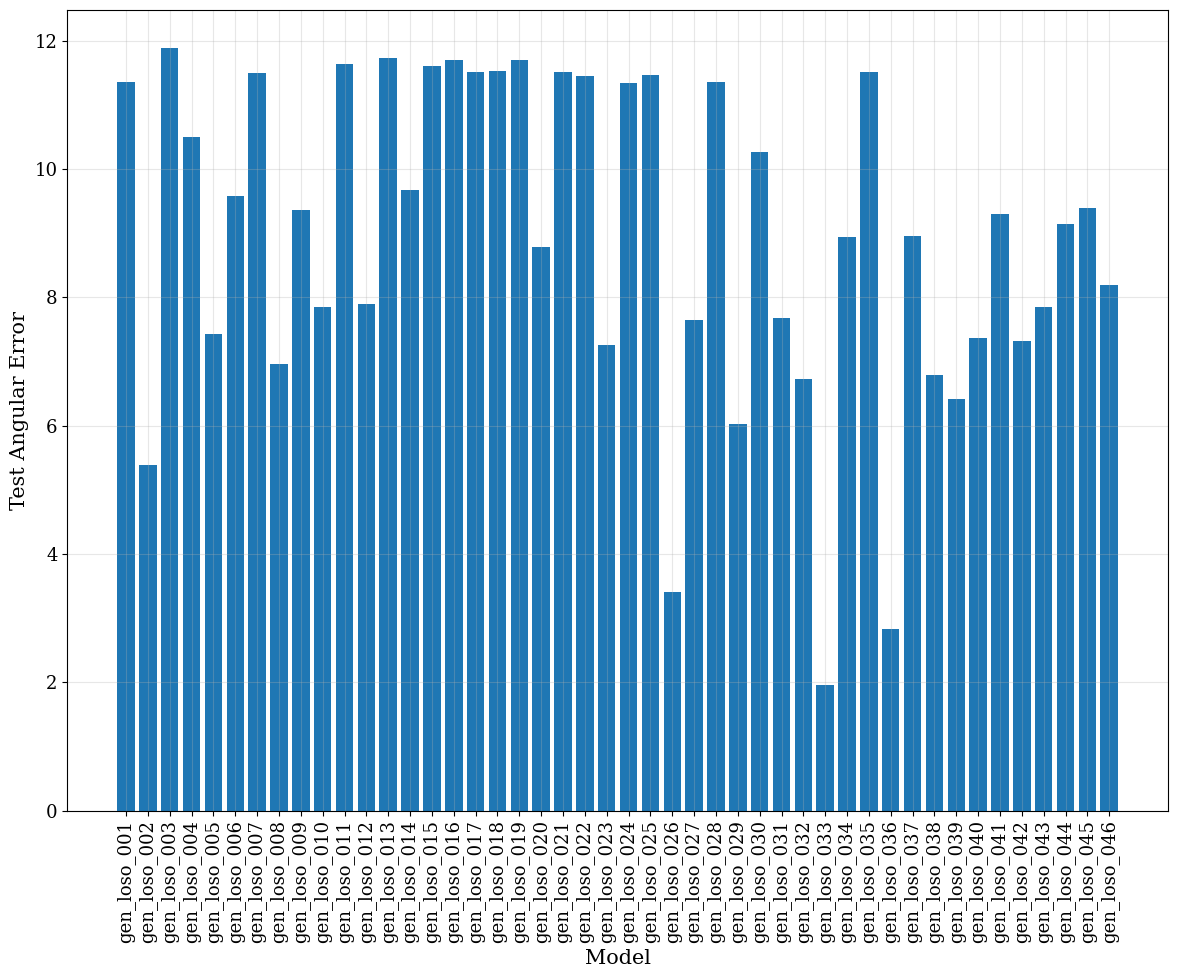

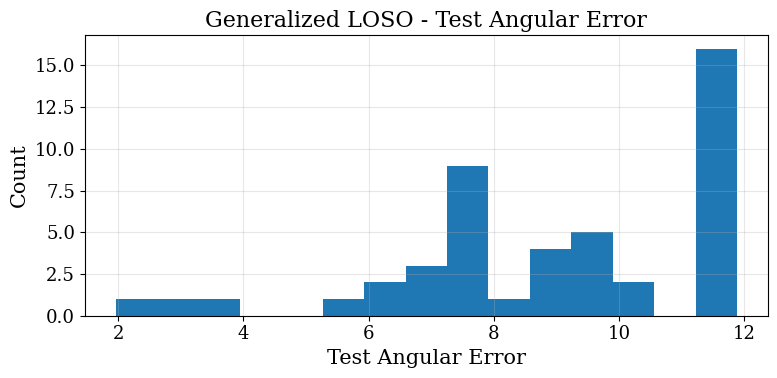

In [3]:
# print("Per-model test performance (Generalized LOSO):")
# display(
#      df_loso[["model_name", "held_out_subject", "test_ang_error"]]
#      .sort_values("held_out_subject")
#      .reset_index(drop=True)
# )

# Plot per-model performance
plot_model_performance(df_loso, EXPERIMENT_NAME)

# Plot distribution of test angular error
plot_error_distribution(df_loso, EXPERIMENT_NAME)

<br/>

## **Experiment: Generalized LOTO**

In [4]:
EXPERIMENT_NAME = "Generalized LOTO"
CSV_PATH = "../results/generalized/gen_loto.csv"
CSV_PATH_RESERVED = "../results/generalized/gen_loto_reserved_eval.csv"

df_loto = load_results(CSV_PATH)
df_loto_reserved = load_results(CSV_PATH_RESERVED)
df_loto.head()

Loaded: ../results/generalized/gen_loto.csv
Models found: 25
Loaded: ../results/generalized/gen_loto_reserved_eval.csv
Models found: 25


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,gen_loto_0,results\models\gen_loto_0.pth,NaN,general_loto,NaN,NaN,0,scratch,92562,1543,2316,17,2.456200,2.465944,2.465944,462.941024,True
1,gen_loto_1,results\models\gen_loto_1.pth,NaN,general_loto,NaN,NaN,1,scratch,92574,1538,2309,26,1.563299,1.659507,1.659507,635.786694,True
2,gen_loto_2,results\models\gen_loto_2.pth,NaN,general_loto,NaN,NaN,2,scratch,92546,1550,2325,20,1.679783,1.569104,1.569104,521.051442,True
3,gen_loto_3,results\models\gen_loto_3.pth,NaN,general_loto,NaN,NaN,3,scratch,92556,1546,2319,20,1.275774,1.317170,1.317170,524.904544,True
4,gen_loto_4,results\models\gen_loto_4.pth,NaN,general_loto,NaN,NaN,4,scratch,92521,1560,2340,26,1.952325,2.068091,2.068091,639.499583,True


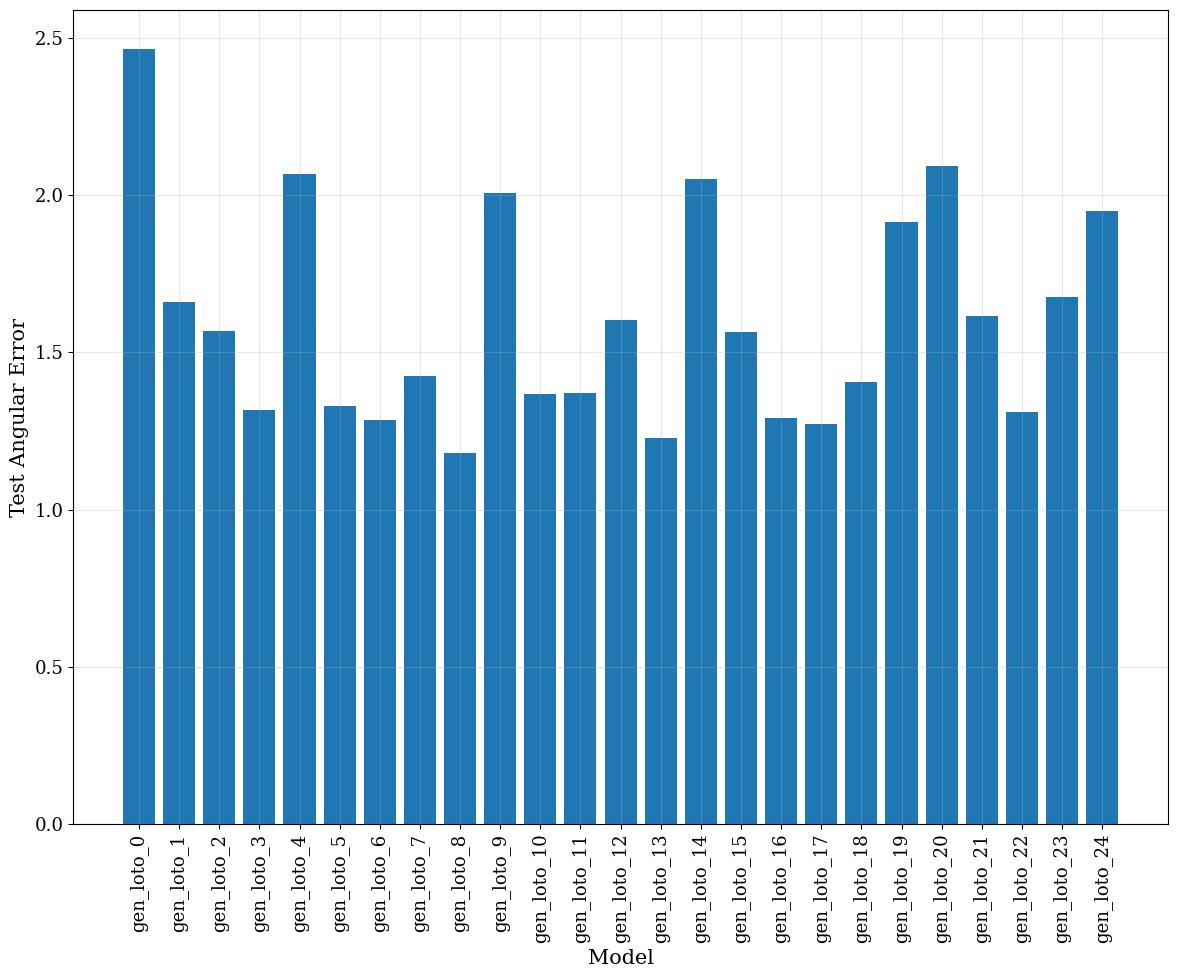

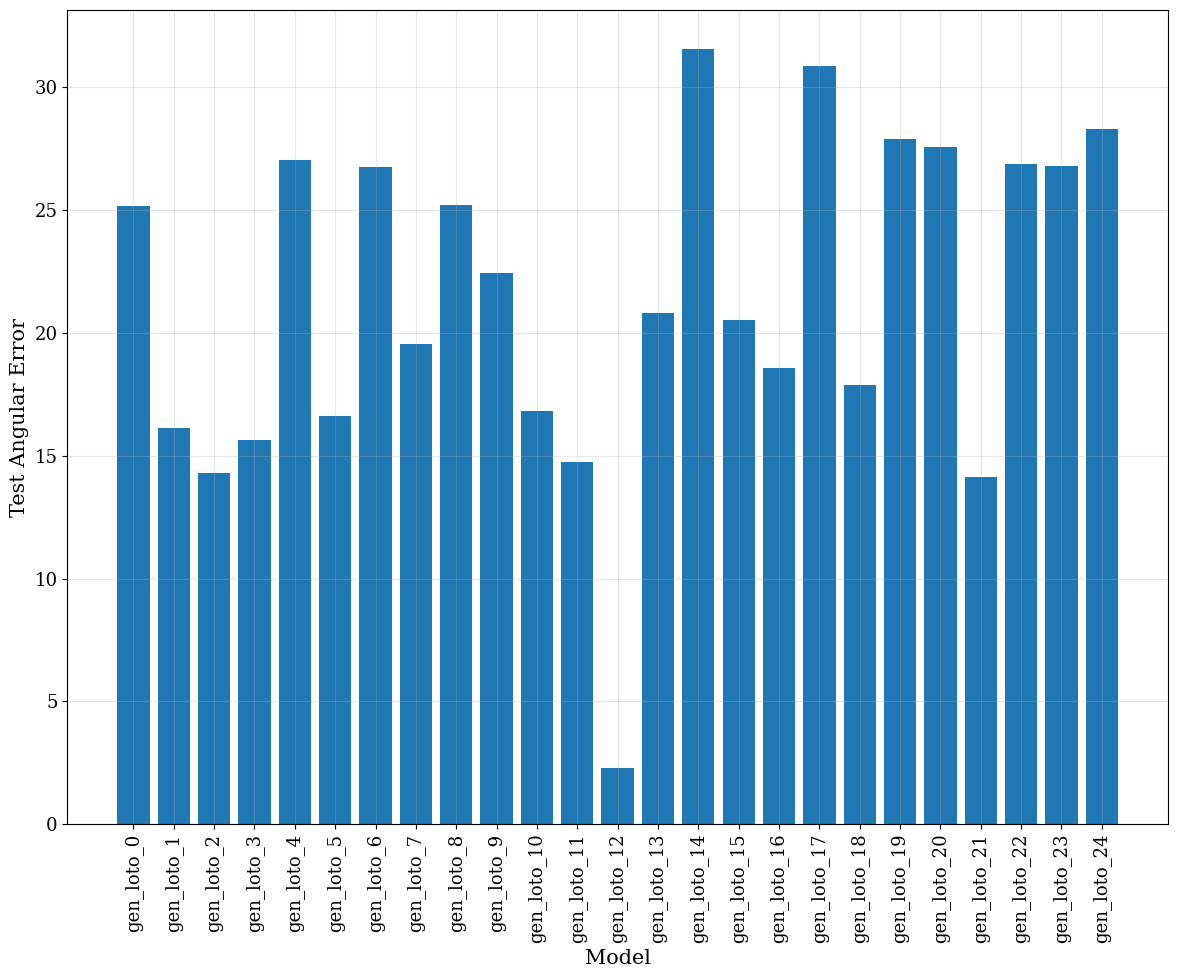

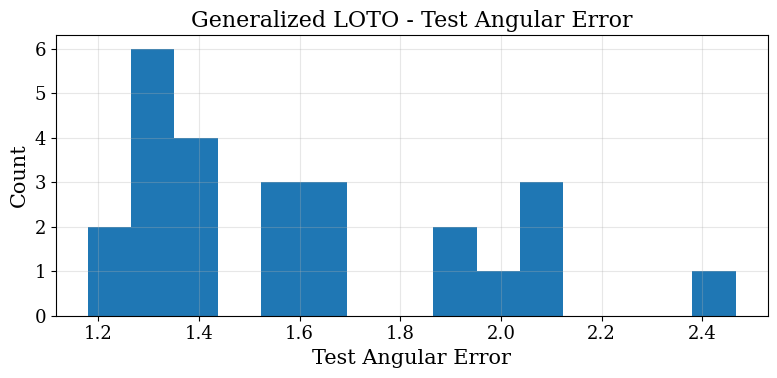

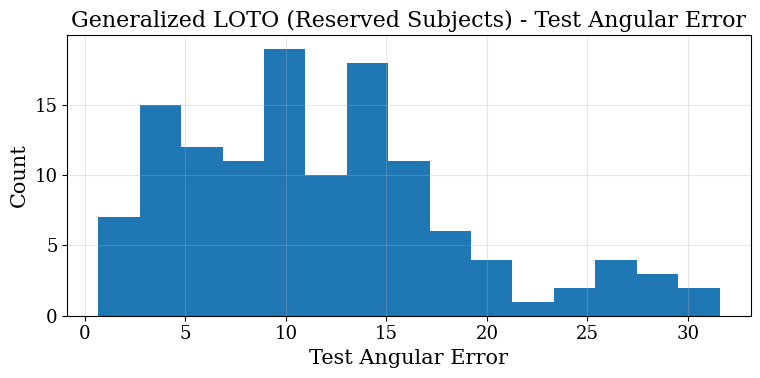

In [5]:
# print("Per-model test performance (Generalized LOTO):")
# display(
#     df_loto[["model_name", "held_out_target", "test_ang_error"]]
#     .sort_values("held_out_target")
#    .reset_index(drop=True)
# )

# print("Per-model test performance (Generalized LOTO - Reserved Subjects):")
# with pd.option_context("display.max_rows", None):
#     display(
#         df_loto_reserved[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
#         .sort_values(["subject_spec_id", "held_out_target"])
#         .reset_index(drop=True)
#     )

plot_model_performance(df_loto, EXPERIMENT_NAME)
plot_model_performance(df_loto_reserved, "Generalized LOTO (Reserved Subjects)")

plot_error_distribution(df_loto, EXPERIMENT_NAME)
plot_error_distribution(df_loto_reserved, "Generalized LOTO (Reserved Subjects)")

<br/>

## **Experiment: Subject-Specific Scratch**

In [6]:
EXPERIMENT_NAME = "Subject-Specific Scratch"
CSV_PATH = "../results/subject_spec/subject_spec_scratch.csv"

df_scratch = load_results(CSV_PATH)
df_scratch.head()

Loaded: ../results/subject_spec/subject_spec_scratch.csv
Models found: 125


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,subject_spec_scratch_002_0,results\models\subject_spec_scratch_002_0.pth,NaN,subject_spec_scratch,2,NaN,0,scratch,2270,38,59,3,15.623033,15.624575,15.624575,81.447464,True
1,subject_spec_scratch_002_1,results\models\subject_spec_scratch_002_1.pth,NaN,subject_spec_scratch,2,NaN,1,scratch,2270,38,59,4,9.873042,9.873680,9.873680,87.293175,True
2,subject_spec_scratch_002_2,results\models\subject_spec_scratch_002_2.pth,NaN,subject_spec_scratch,2,NaN,2,scratch,2275,36,56,5,8.358663,8.354983,8.354983,89.728735,True
3,subject_spec_scratch_002_3,results\models\subject_spec_scratch_002_3.pth,NaN,subject_spec_scratch,2,NaN,3,scratch,2270,38,59,1,11.395574,11.396182,11.396182,61.182183,True
4,subject_spec_scratch_002_4,results\models\subject_spec_scratch_002_4.pth,NaN,subject_spec_scratch,2,NaN,4,scratch,2270,38,59,1,15.937071,15.930118,15.930118,61.142442,True


### Combined Results

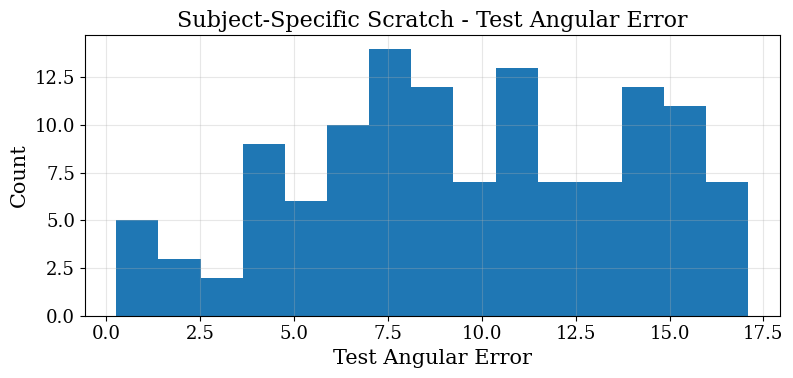

In [7]:
# print("Per-model test performance (Subject-Specific Scratch):")
# with pd.option_context("display.max_rows", None):
#     display(
#         df_scratch[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
#         .sort_values(["subject_spec_id","held_out_target"])
#         .reset_index(drop=True)
#     )

# Plot distribution of test angular error
plot_error_distribution(df_scratch, EXPERIMENT_NAME)

### Per-Subject Results

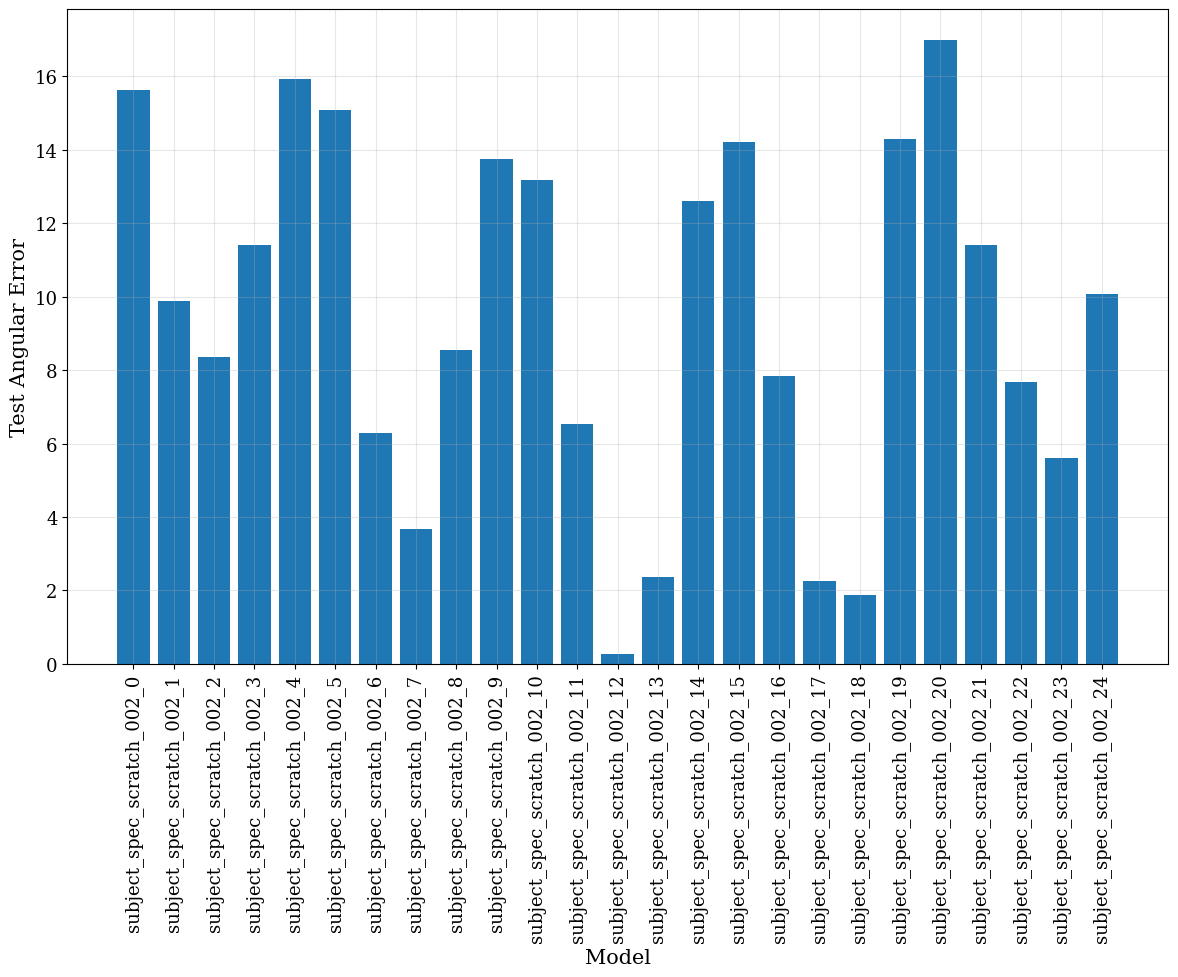

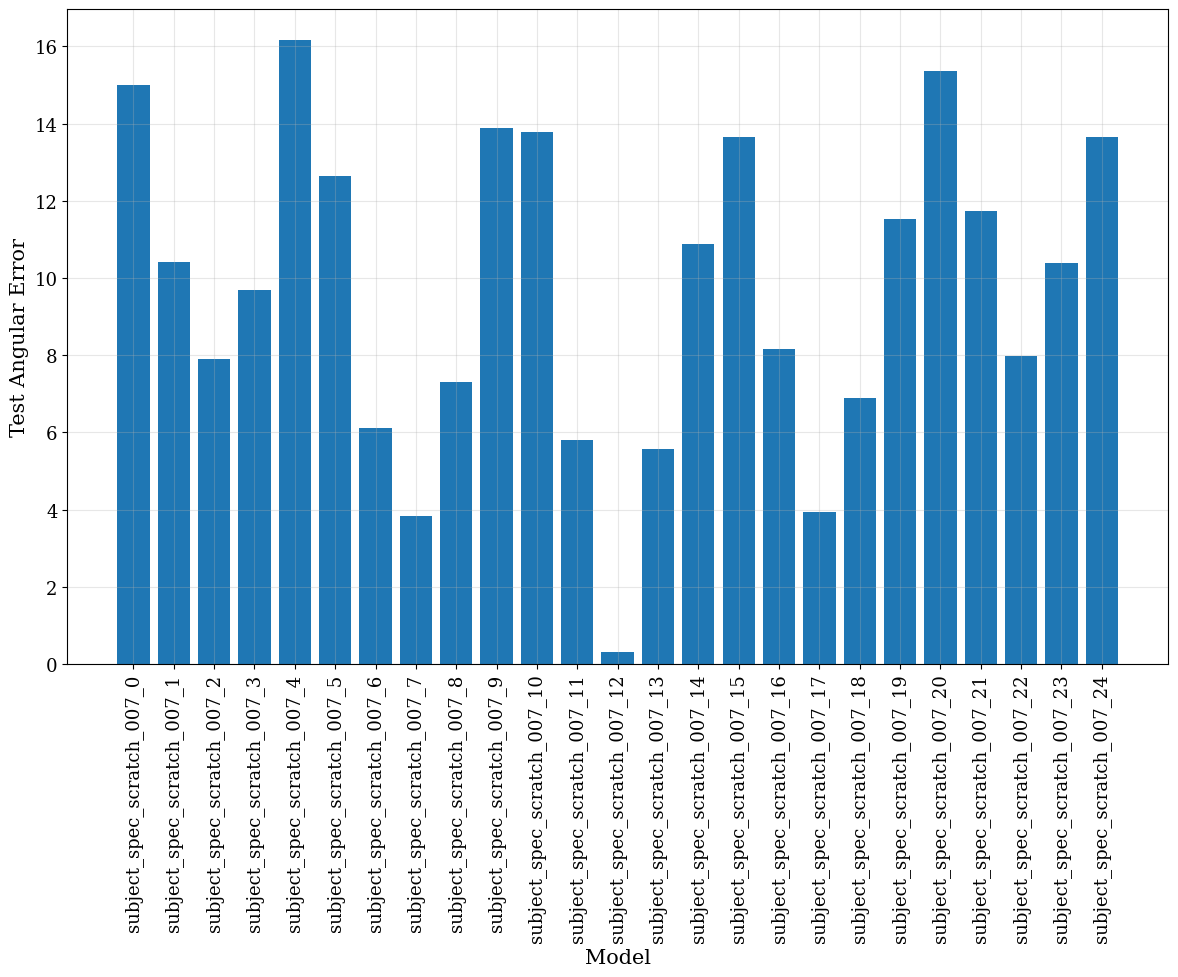

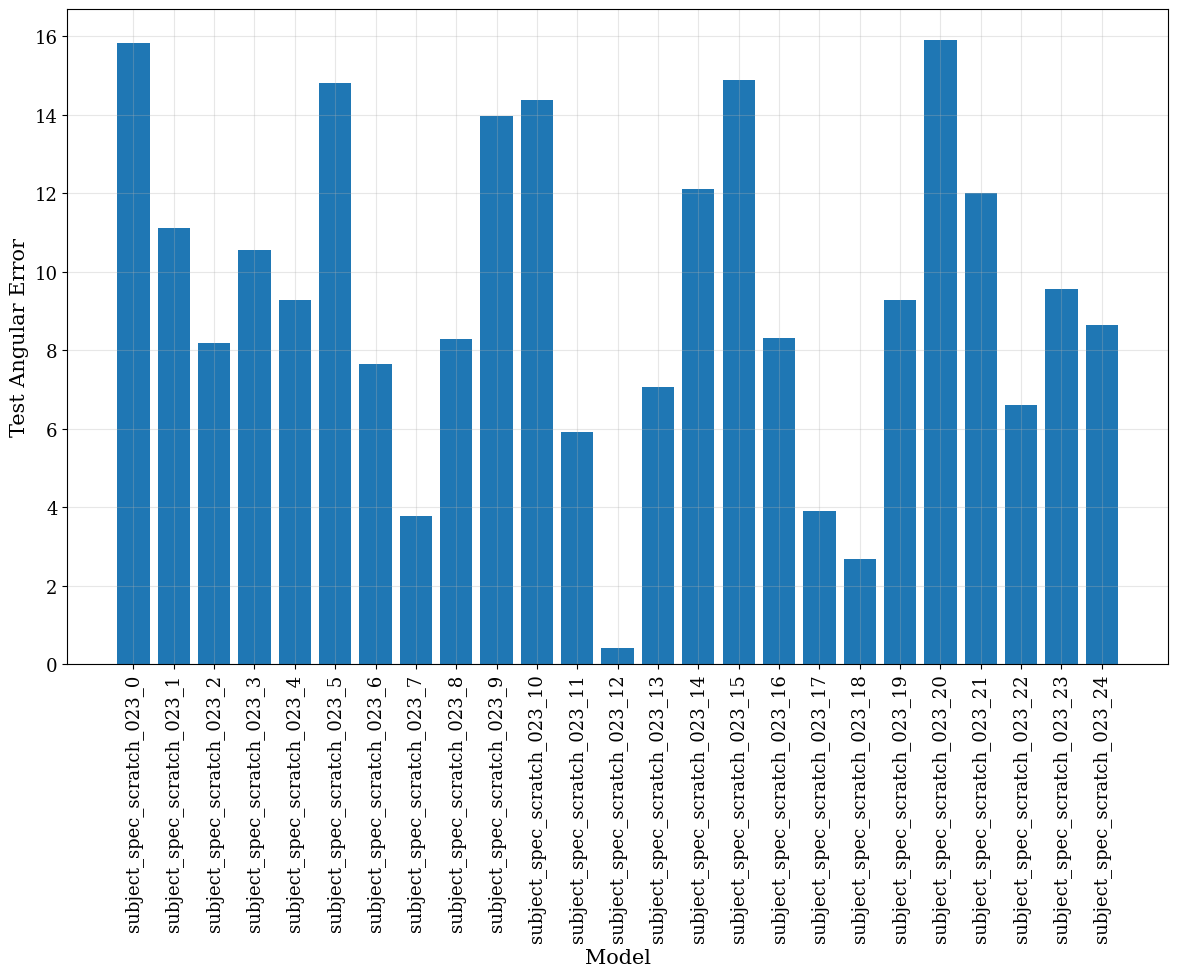

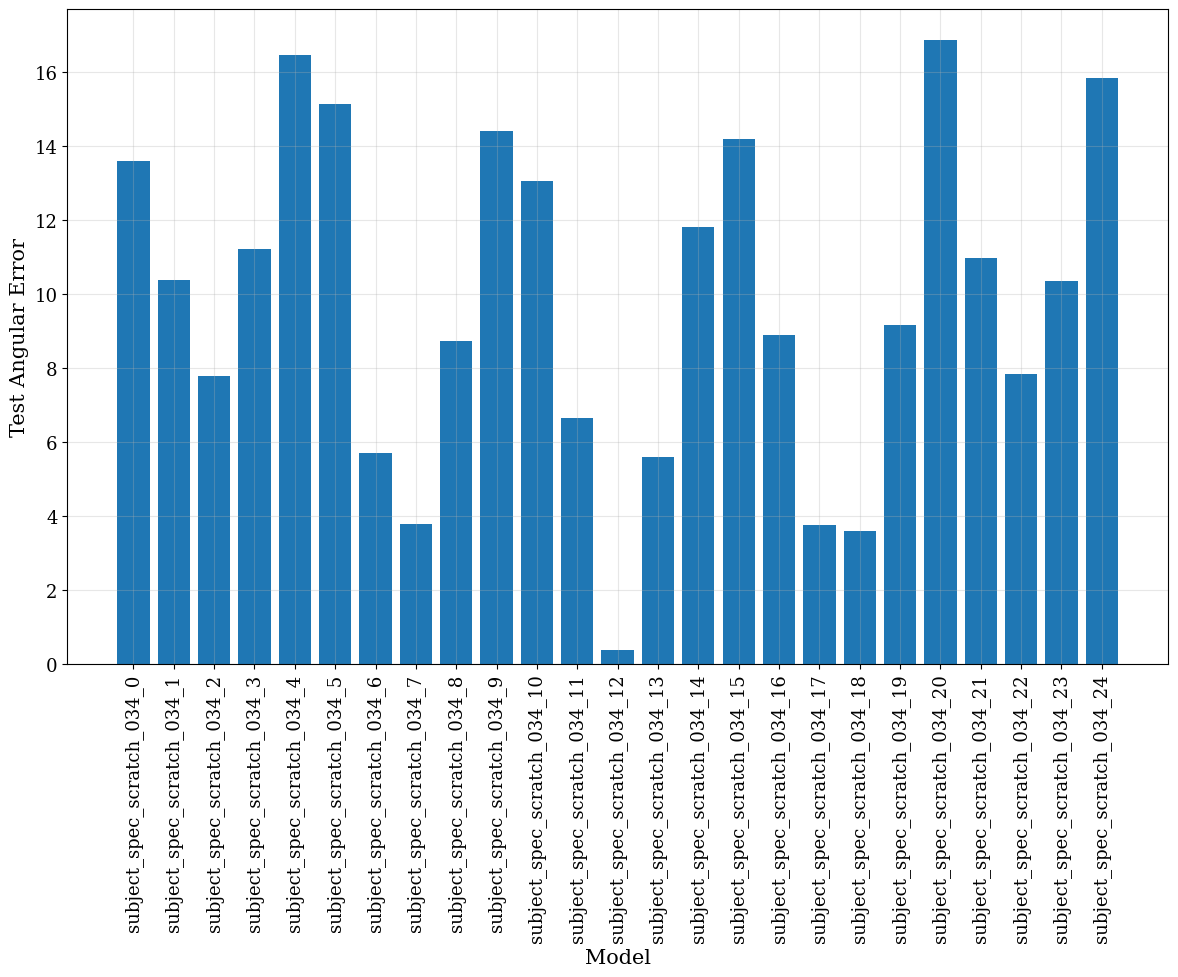

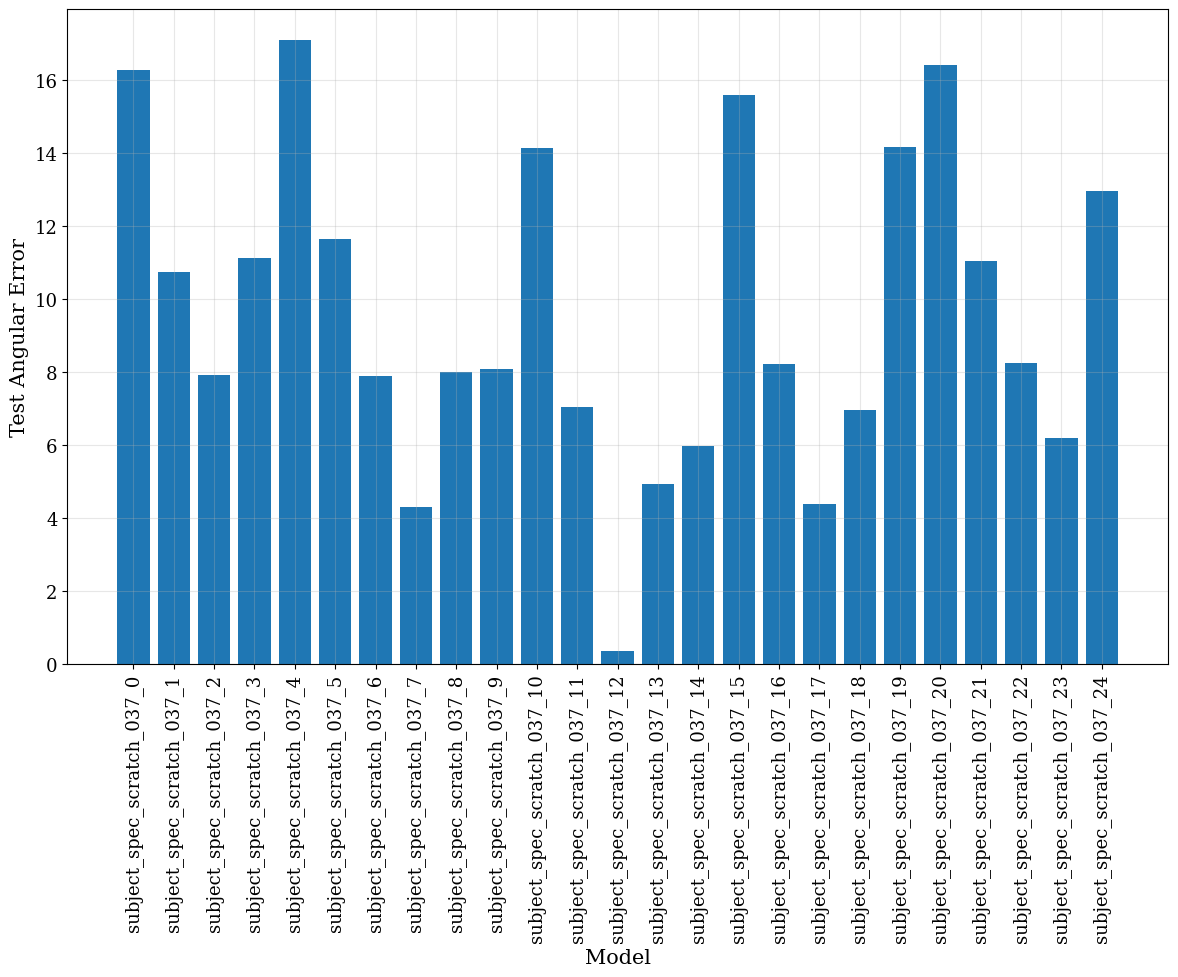

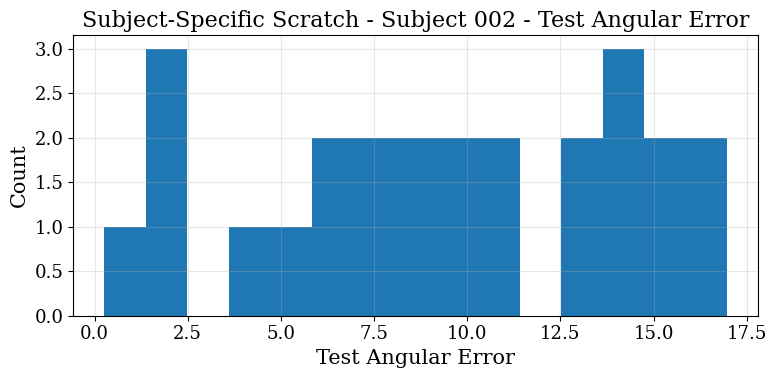

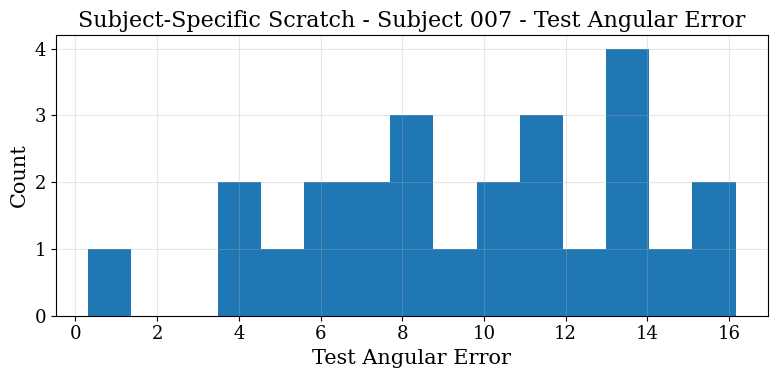

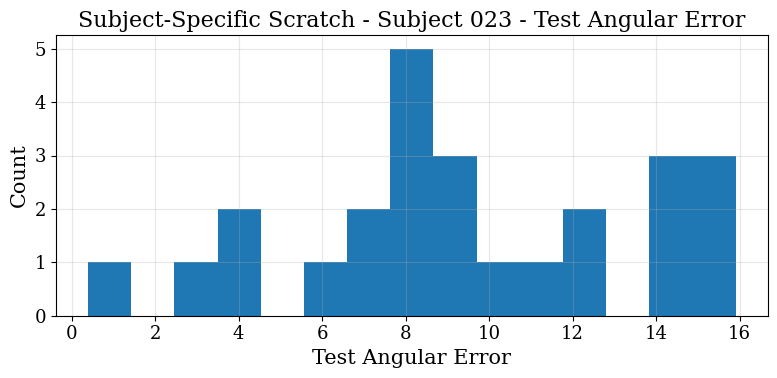

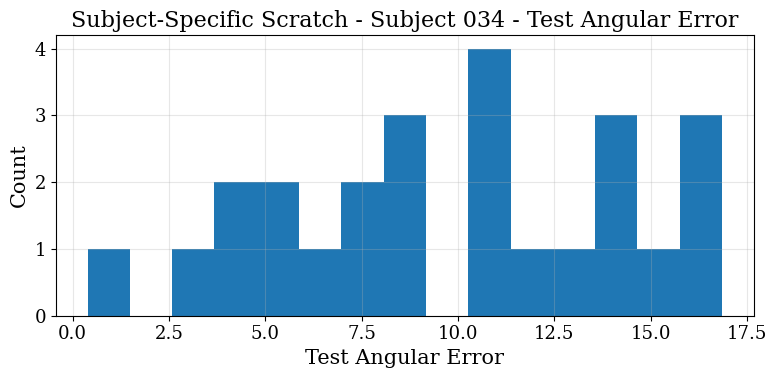

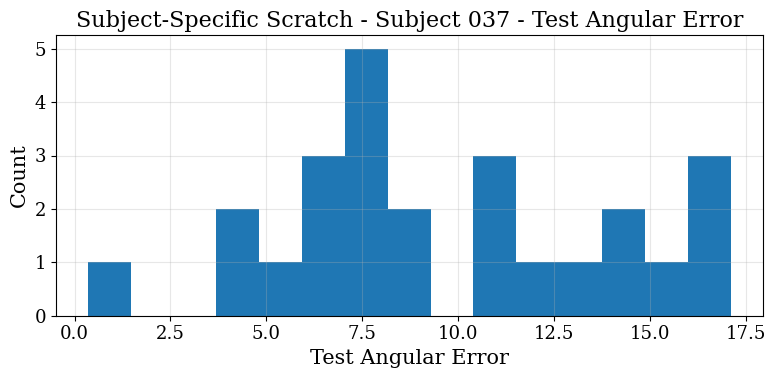

<Figure size 800x500 with 0 Axes>

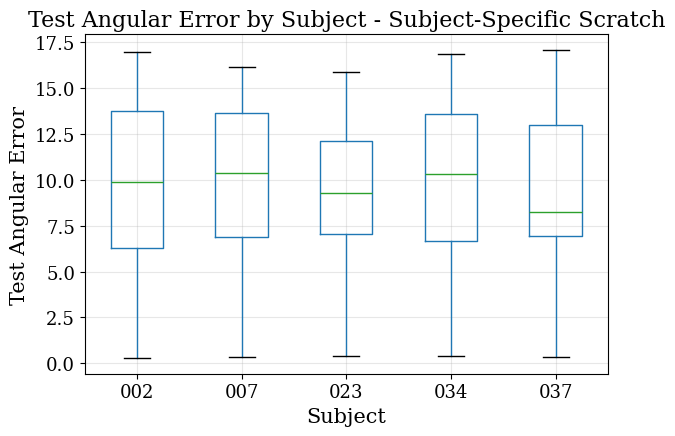

In [8]:
# show_subject_specific_tables(df_scratch, EXPERIMENT_NAME)
plot_subject_specific_model_performance(df_scratch, EXPERIMENT_NAME)
plot_subject_specific_error_distribution(df_scratch, EXPERIMENT_NAME)
plot_subject_specific_boxplots(df_scratch, EXPERIMENT_NAME)

<br/>

## **Experiment: Subject-Specific Transfer (Head Only)**

In [9]:
EXPERIMENT_NAME = "Subject-Specific Transfer (Head Only)"
CSV_PATH = "../results/subject_spec/subject_spec_transfer_head_only.csv"

df_transfer_head = load_results(CSV_PATH)
df_transfer_head.head()

Loaded: ../results/subject_spec/subject_spec_transfer_head_only.csv
Models found: 125


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,transfer_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,subject_spec_transfer_head_only_002_0,results\models\subject_spec_transfer_head_only...,results\models\gen_loto_0.pth,subject_spec_transfer,2,NaN,0,transfer,head_only,2270,38,59,1,1.639929,1.648463,1.648463,13.152746,True
1,subject_spec_transfer_head_only_002_1,results\models\subject_spec_transfer_head_only...,results\models\gen_loto_1.pth,subject_spec_transfer,2,NaN,1,transfer,head_only,2270,38,59,9,0.824926,0.658274,0.658274,14.331330,True
2,subject_spec_transfer_head_only_002_2,results\models\subject_spec_transfer_head_only...,results\models\gen_loto_2.pth,subject_spec_transfer,2,NaN,2,transfer,head_only,2275,36,56,8,0.527947,0.414319,0.414319,14.638831,True
3,subject_spec_transfer_head_only_002_3,results\models\subject_spec_transfer_head_only...,results\models\gen_loto_3.pth,subject_spec_transfer,2,NaN,3,transfer,head_only,2270,38,59,1,1.171466,1.127114,1.127114,12.556213,True
4,subject_spec_transfer_head_only_002_4,results\models\subject_spec_transfer_head_only...,results\models\gen_loto_4.pth,subject_spec_transfer,2,NaN,4,transfer,head_only,2270,38,59,6,1.327978,1.196854,1.196854,13.791234,True


### Combined Results

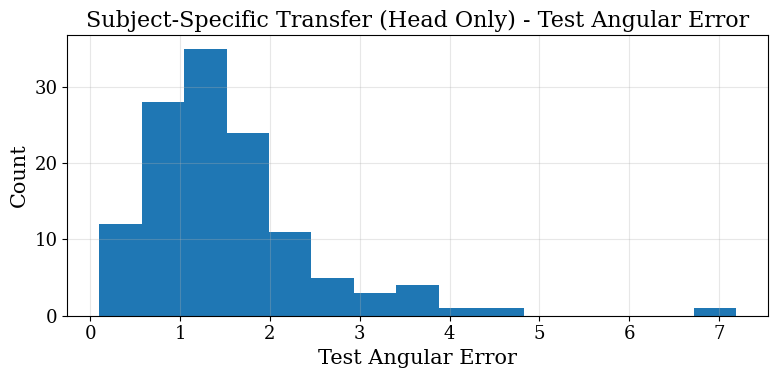

In [10]:
# print("Per-model test performance (Subject-Specific Transfer - Head Only):")
# with pd.option_context("display.max_rows", None):
    # display(
        # df_transfer_head[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
        # .sort_values("test_ang_error")
        # .reset_index(drop=True)
    # )

# Plot distribution of test angular error
plot_error_distribution(df_transfer_head, EXPERIMENT_NAME)

### Per-Subject Results

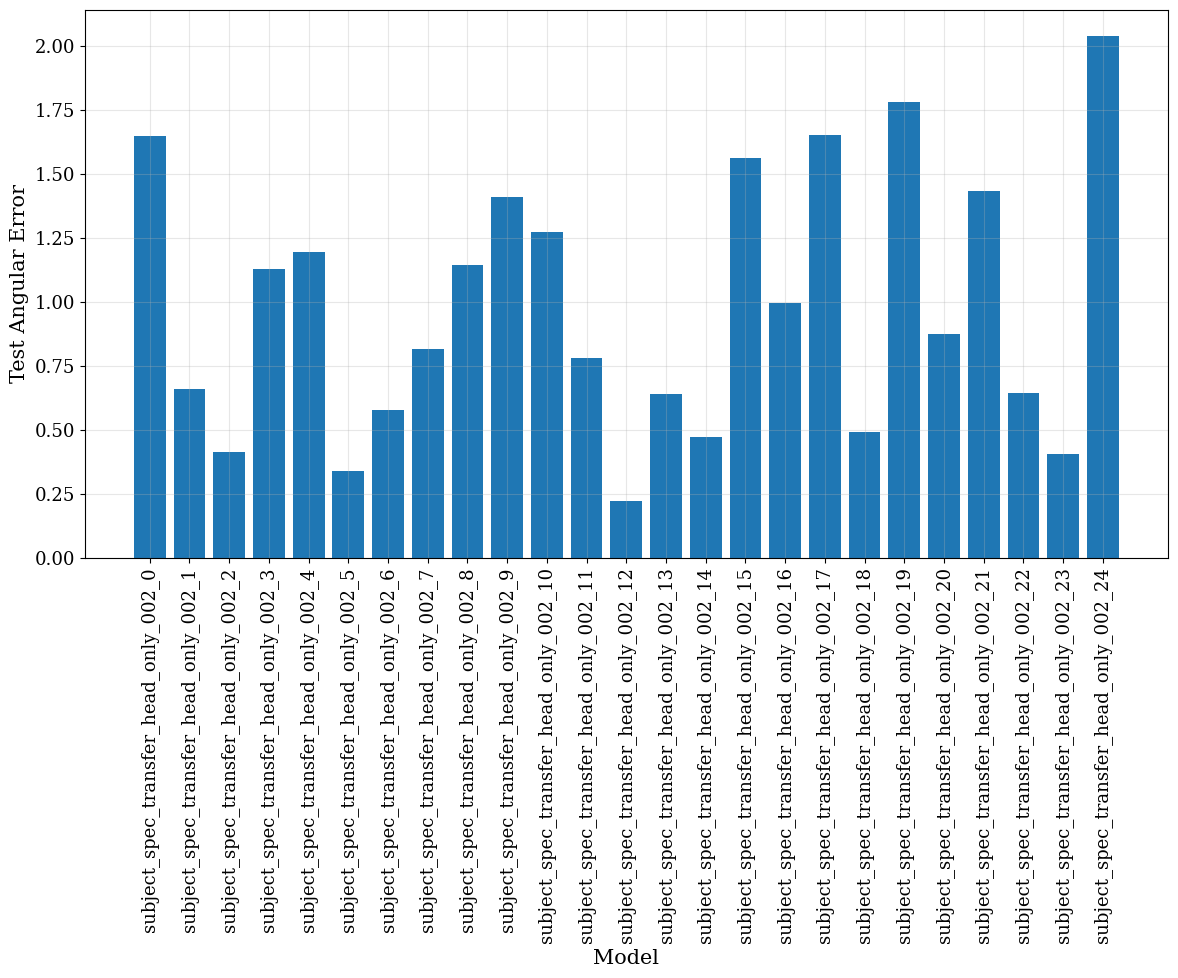

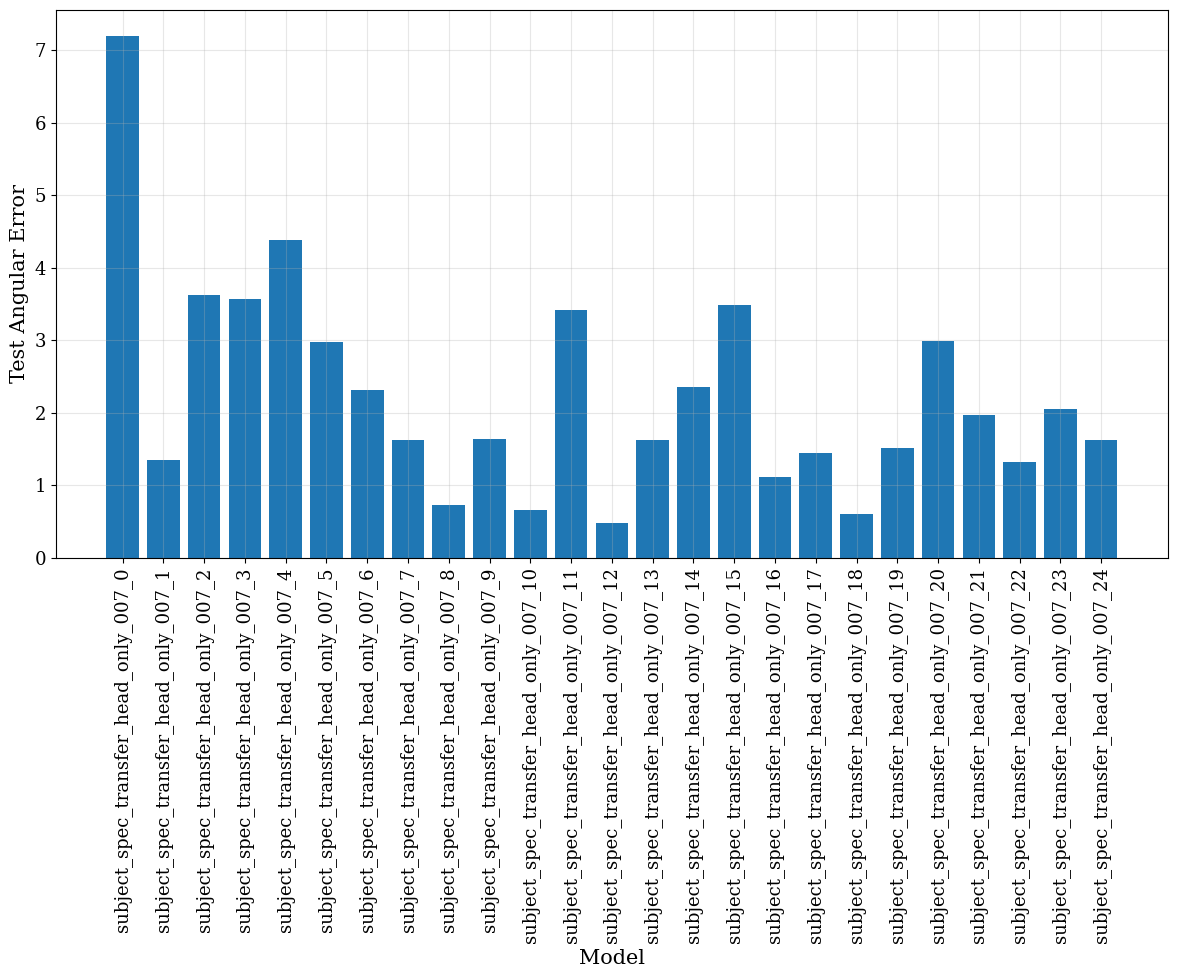

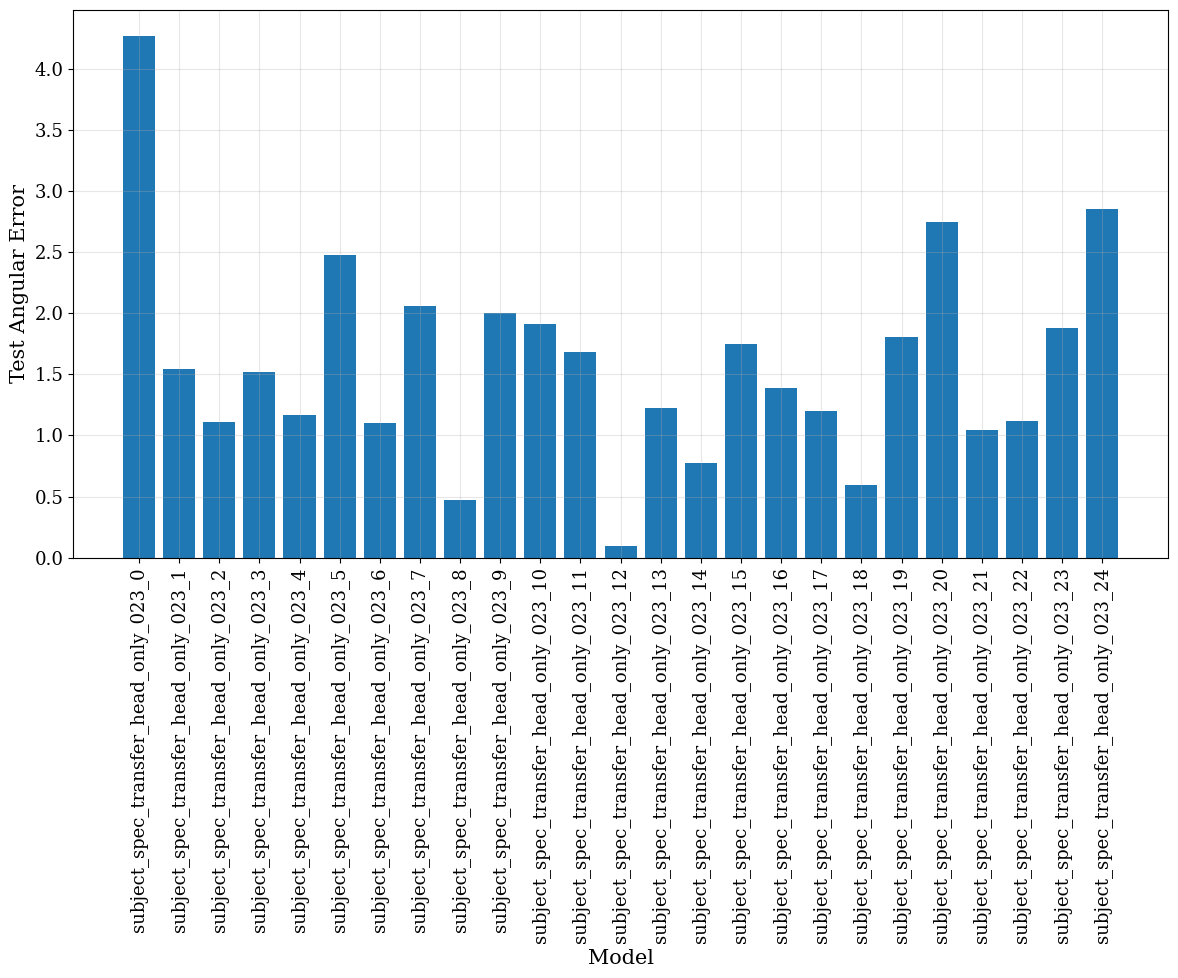

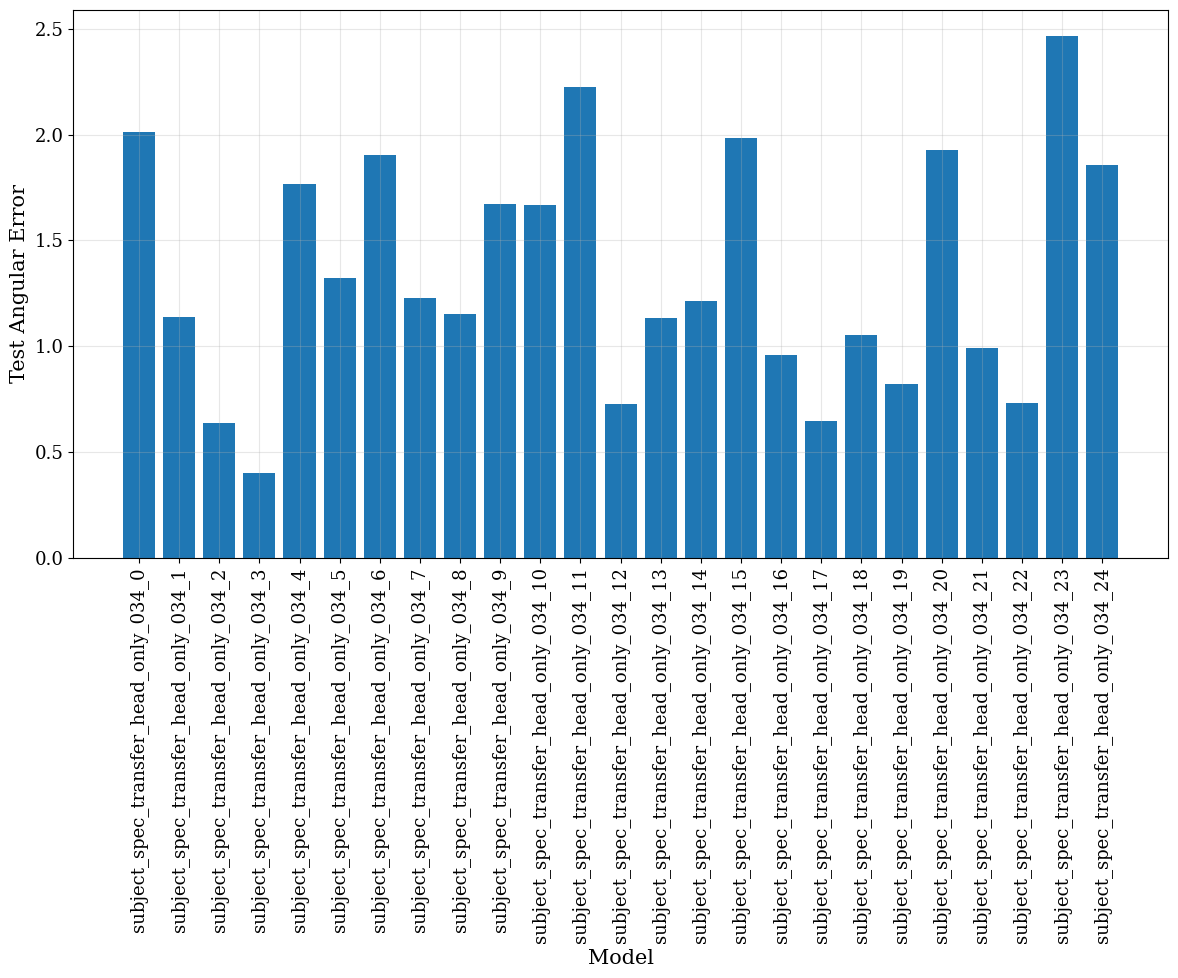

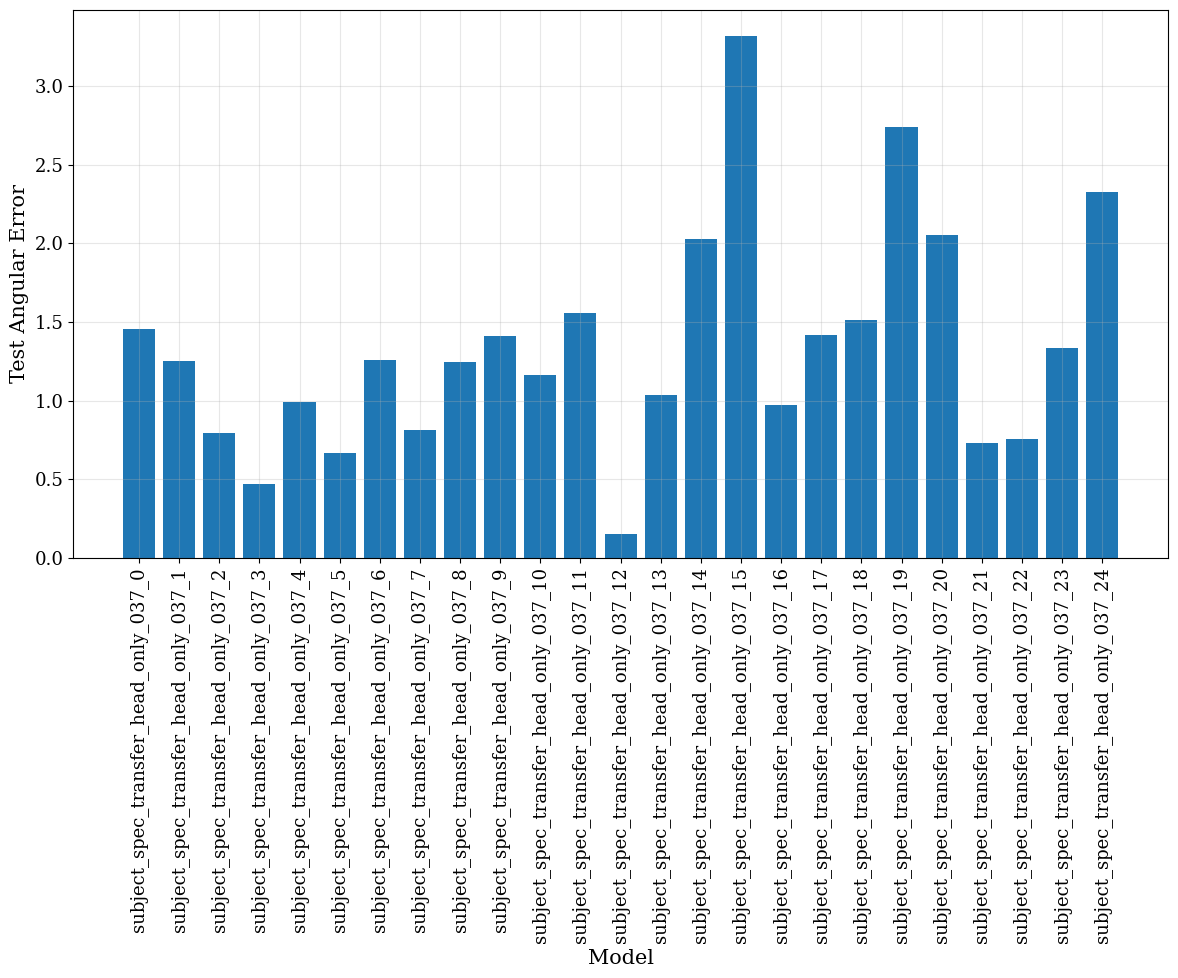

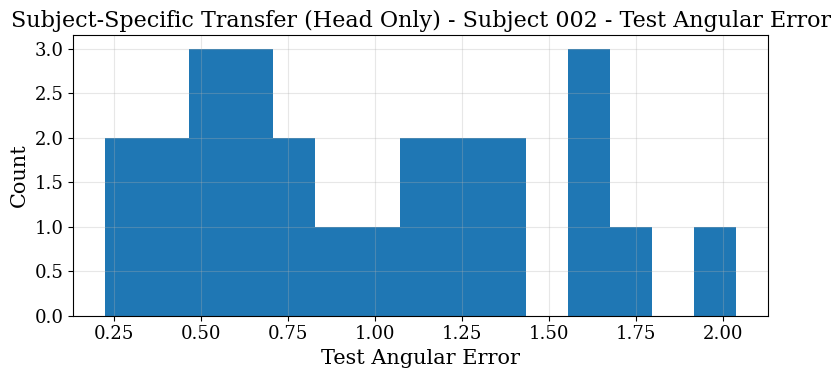

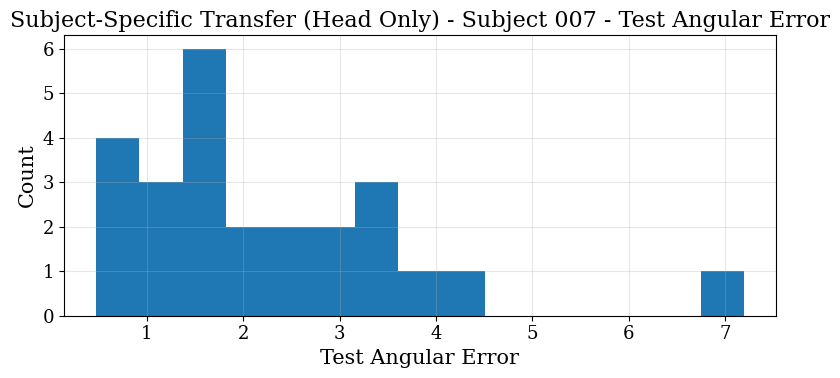

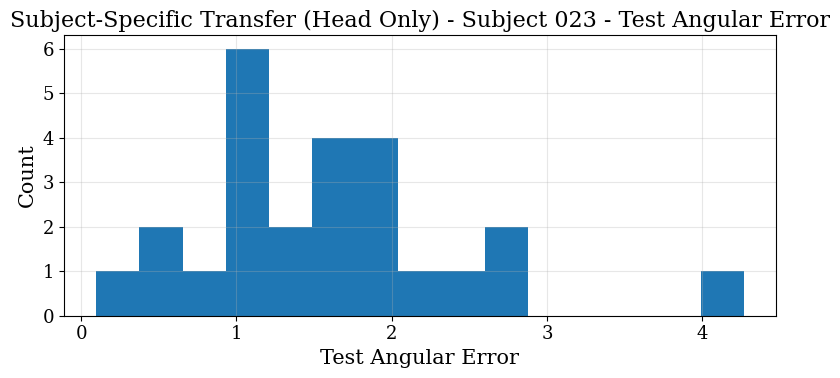

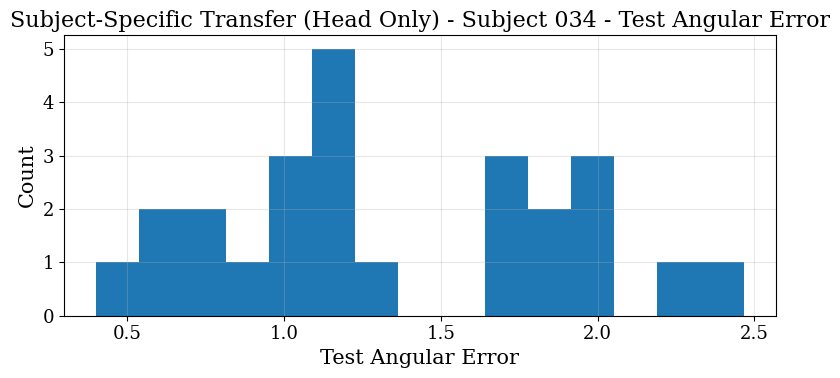

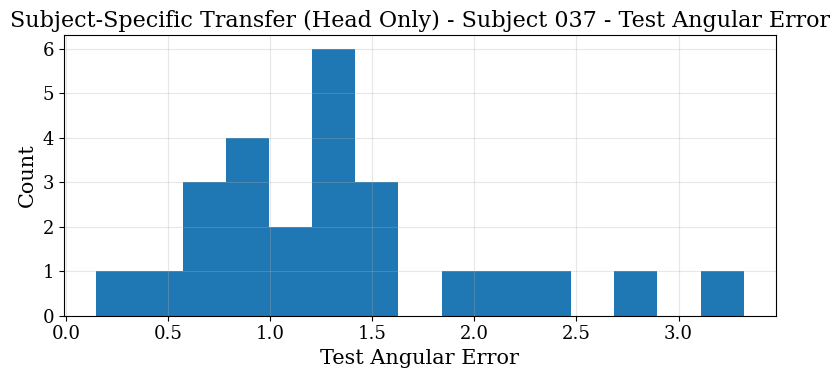

<Figure size 800x500 with 0 Axes>

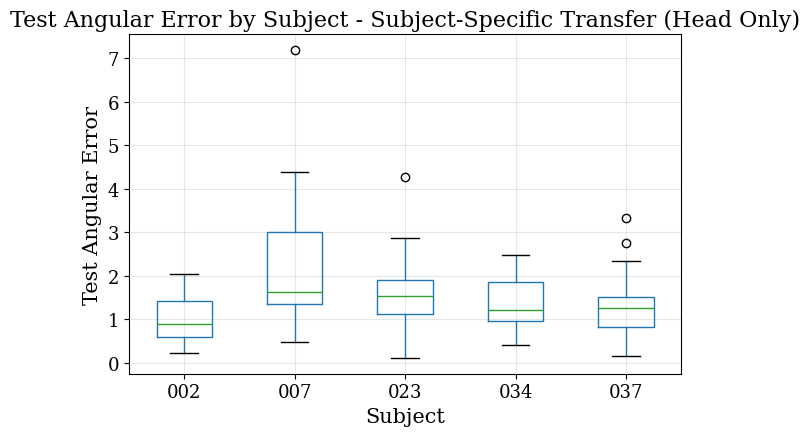

In [11]:
# show_subject_specific_tables(df_transfer_head, EXPERIMENT_NAME)
plot_subject_specific_model_performance(df_transfer_head, EXPERIMENT_NAME)
plot_subject_specific_error_distribution(df_transfer_head, EXPERIMENT_NAME)
plot_subject_specific_boxplots(df_transfer_head, EXPERIMENT_NAME)

<br/>

## **Experiment: Subject-Specific Transfer (Last Conv)**

In [12]:
EXPERIMENT_NAME = "Subject-Specific Transfer (Last Conv)"
CSV_PATH = "../results/subject_spec/subject_spec_transfer_last_conv.csv"

df_transfer_last_1_conv = load_results(CSV_PATH)
df_transfer_last_1_conv.head()

Loaded: ../results/subject_spec/subject_spec_transfer_last_conv.csv
Models found: 125


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,transfer_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,subject_spec_transfer_last_conv_002_0,results\models\subject_spec_transfer_last_conv...,results\models\gen_loto_0.pth,subject_spec_transfer,2,NaN,0,transfer,last_conv,2270,38,59,1,1.169683,1.172719,1.172719,38.016600,True
1,subject_spec_transfer_last_conv_002_1,results\models\subject_spec_transfer_last_conv...,results\models\gen_loto_1.pth,subject_spec_transfer,2,NaN,1,transfer,last_conv,2270,38,59,4,0.714129,0.576134,0.576134,49.589878,True
2,subject_spec_transfer_last_conv_002_2,results\models\subject_spec_transfer_last_conv...,results\models\gen_loto_2.pth,subject_spec_transfer,2,NaN,2,transfer,last_conv,2275,36,56,3,0.523869,0.429315,0.429315,45.119462,True
3,subject_spec_transfer_last_conv_002_3,results\models\subject_spec_transfer_last_conv...,results\models\gen_loto_3.pth,subject_spec_transfer,2,NaN,3,transfer,last_conv,2270,38,59,2,0.660913,0.603869,0.603869,40.387796,True
4,subject_spec_transfer_last_conv_002_4,results\models\subject_spec_transfer_last_conv...,results\models\gen_loto_4.pth,subject_spec_transfer,2,NaN,4,transfer,last_conv,2270,38,59,2,1.690493,1.592925,1.592925,39.882187,True


### Combined Results

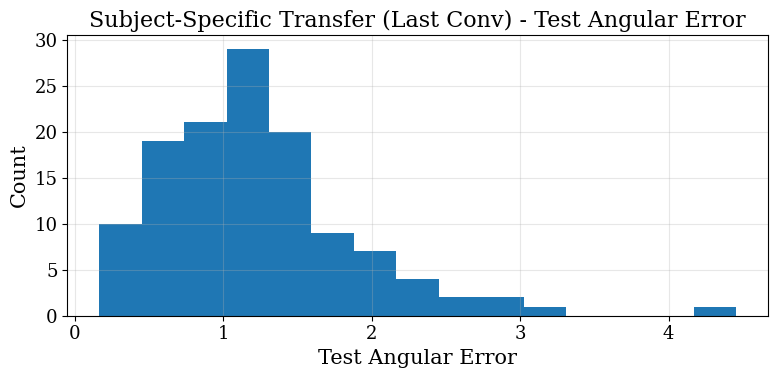

In [13]:
# print("Per-model test performance (Subject-Specific Transfer - Last Conv):")
# with pd.option_context("display.max_rows", None):
    # display(
        # df_transfer_last_1_conv[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
        # .sort_values("test_ang_error")
        # .reset_index(drop=True)
    # )

# Plot distribution of test angular error
plot_error_distribution(df_transfer_last_1_conv, EXPERIMENT_NAME)

### Per-Subject Results

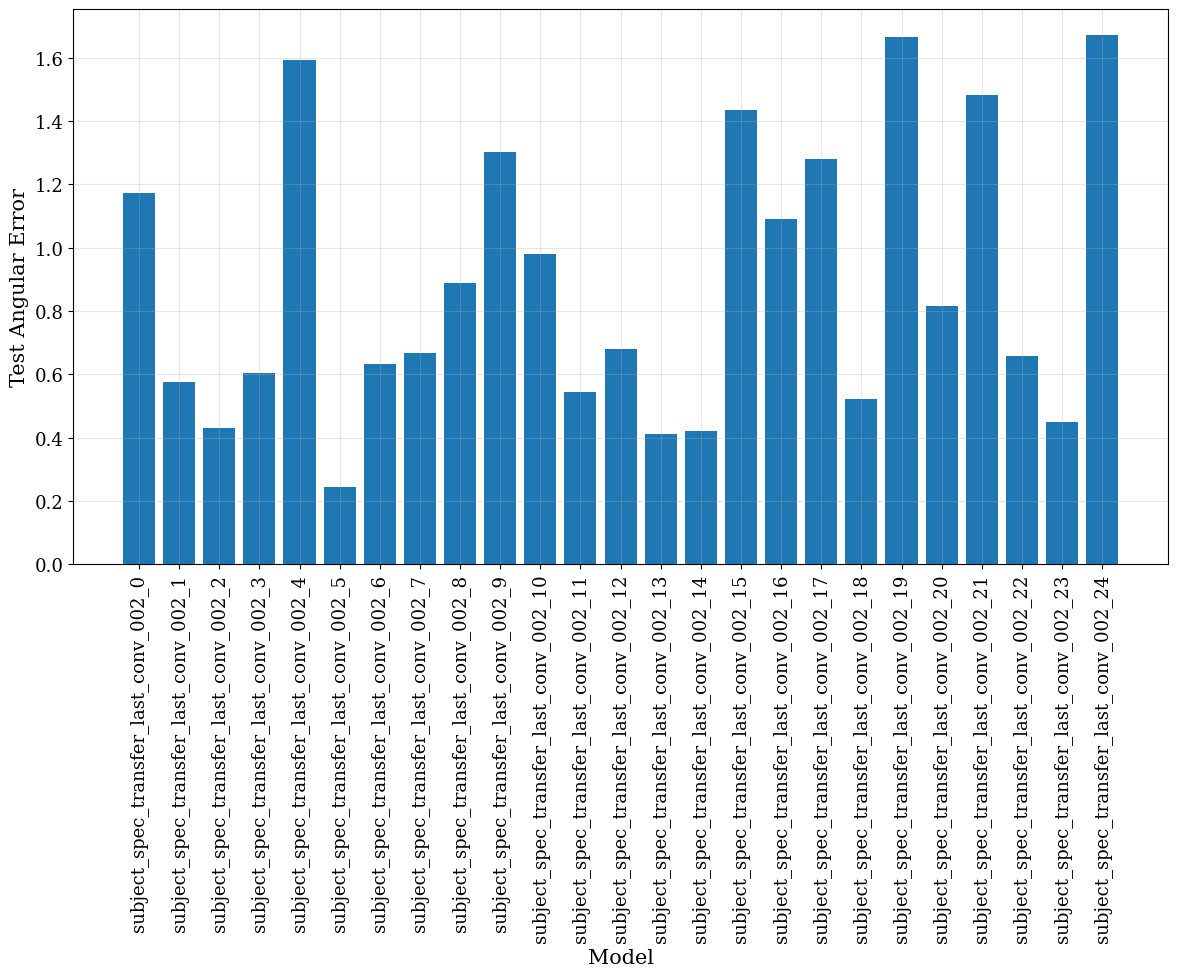

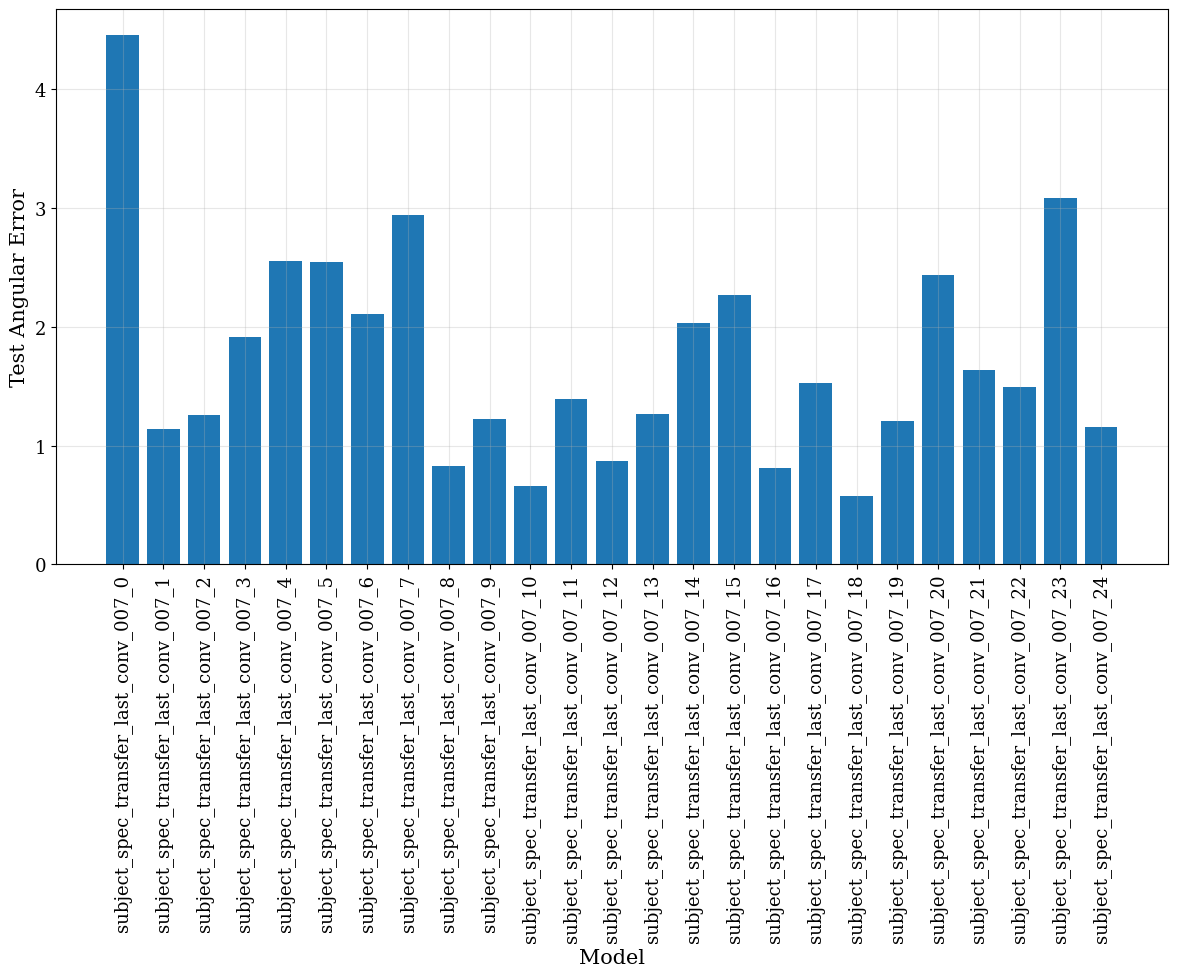

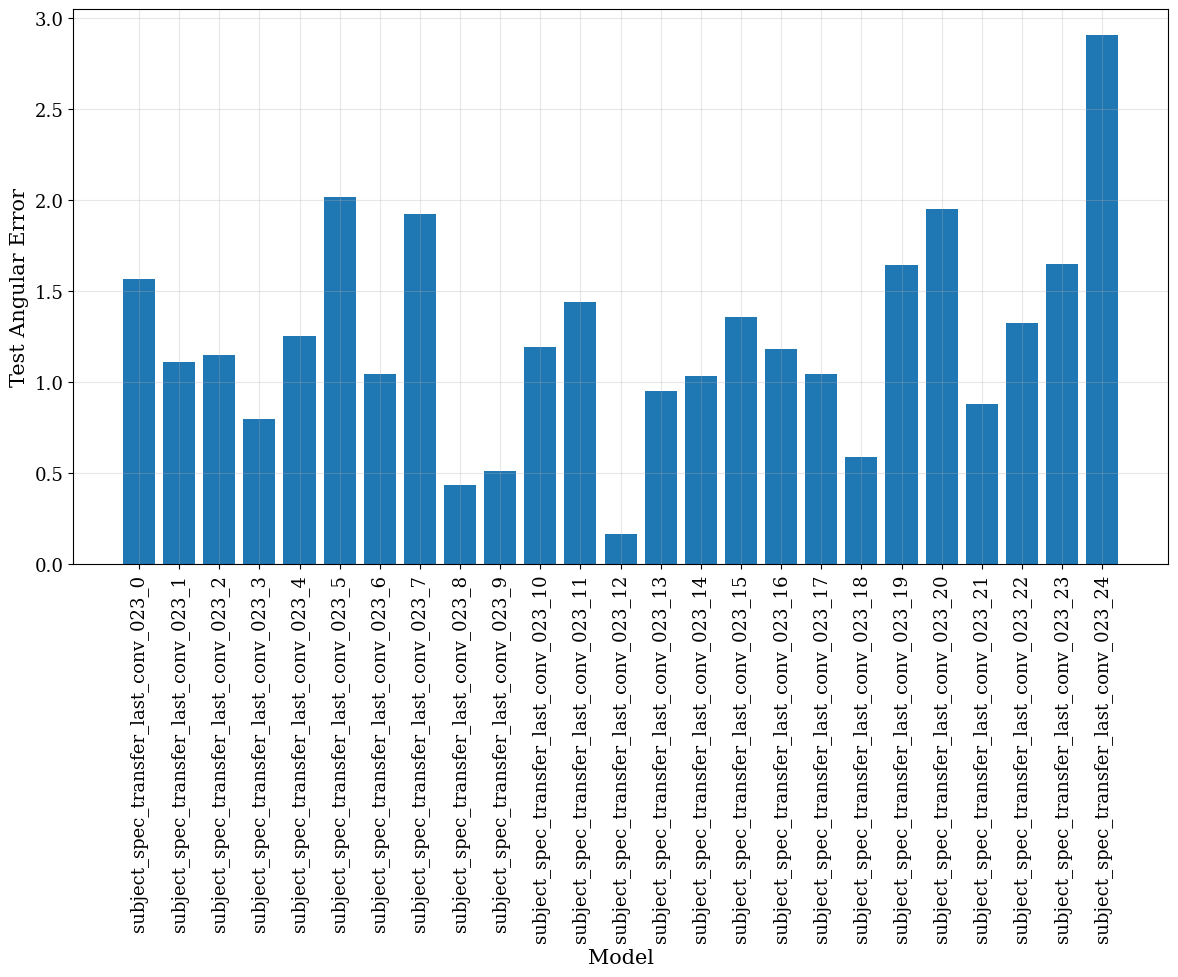

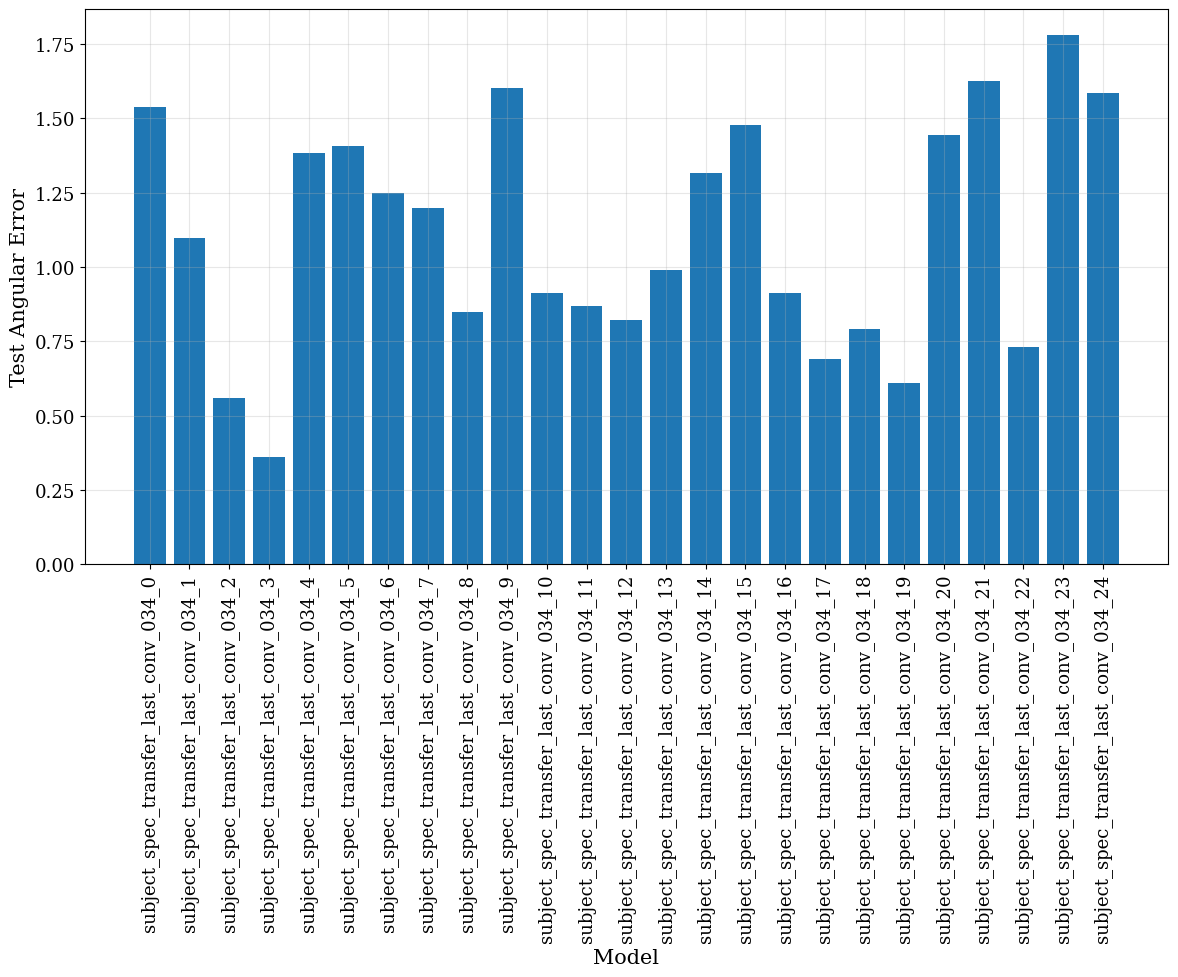

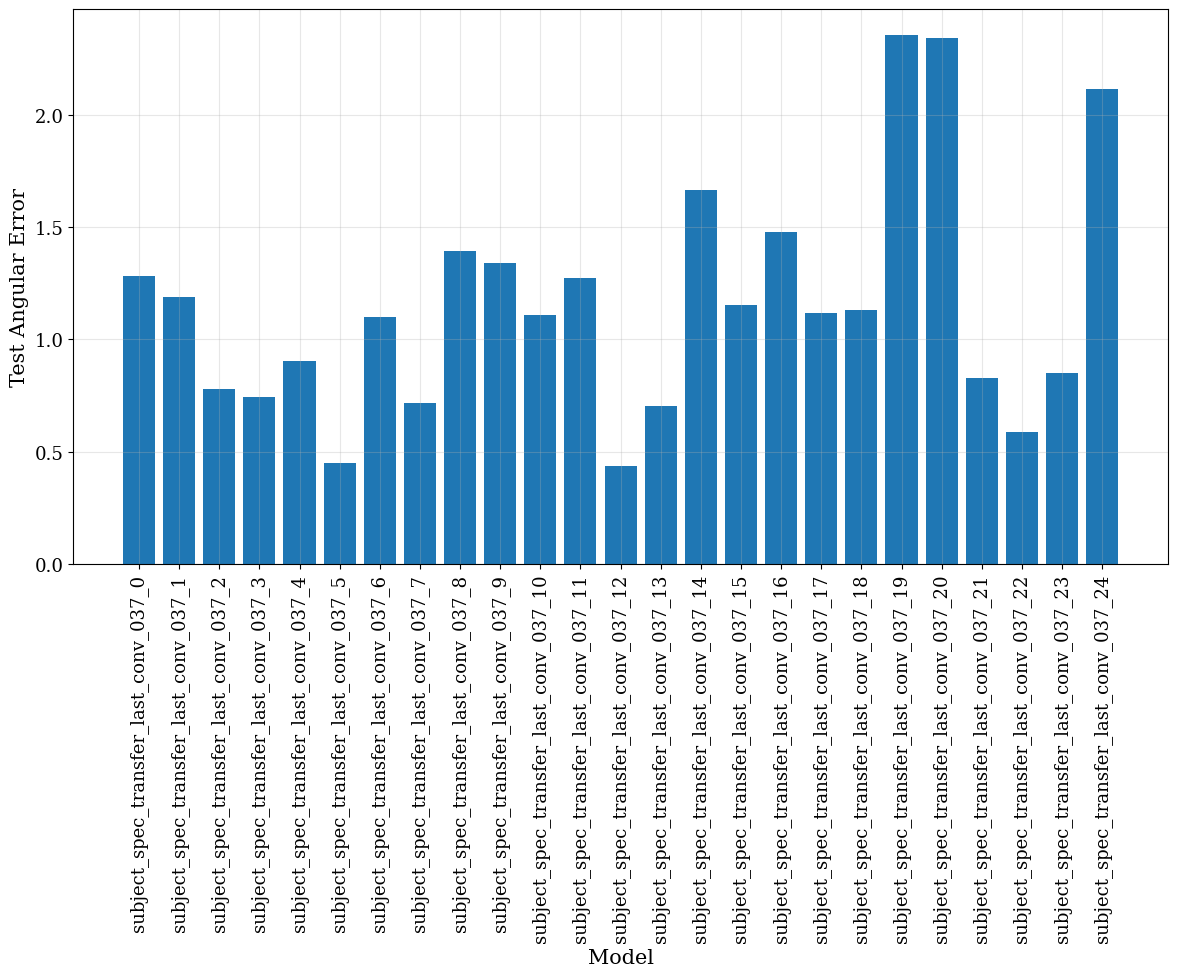

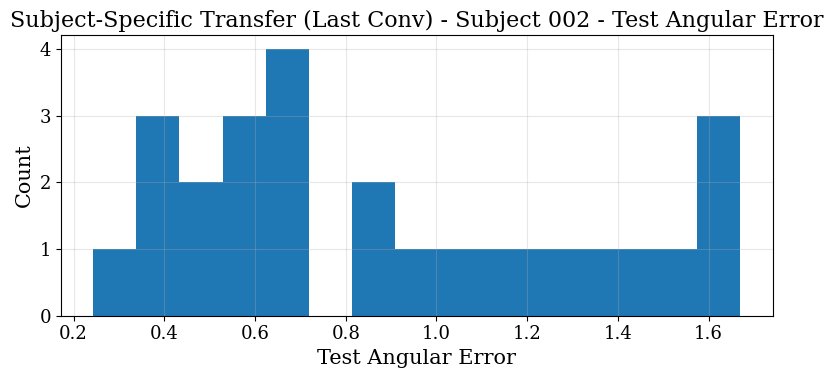

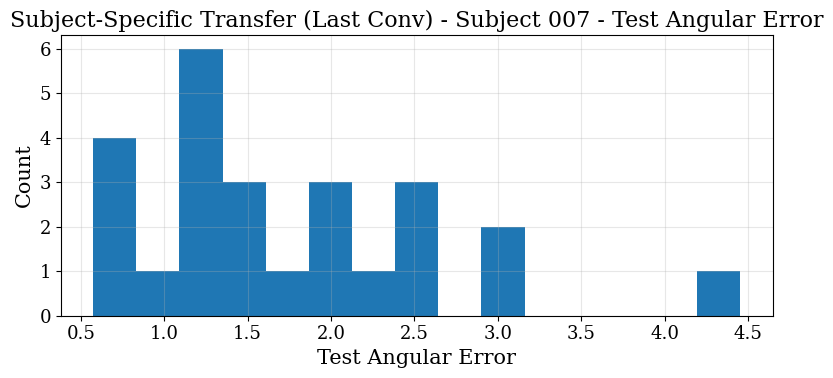

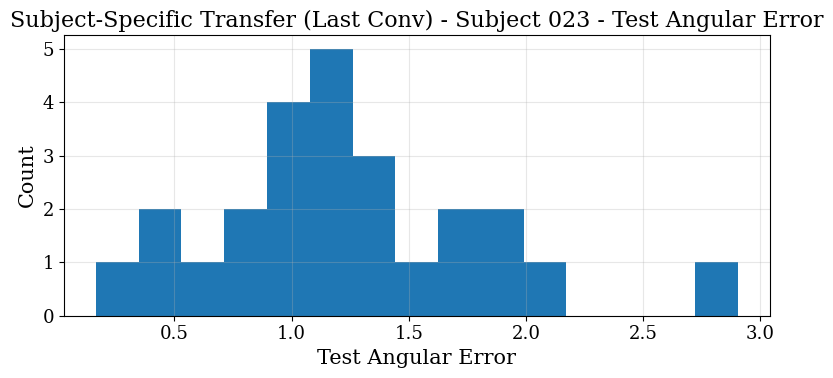

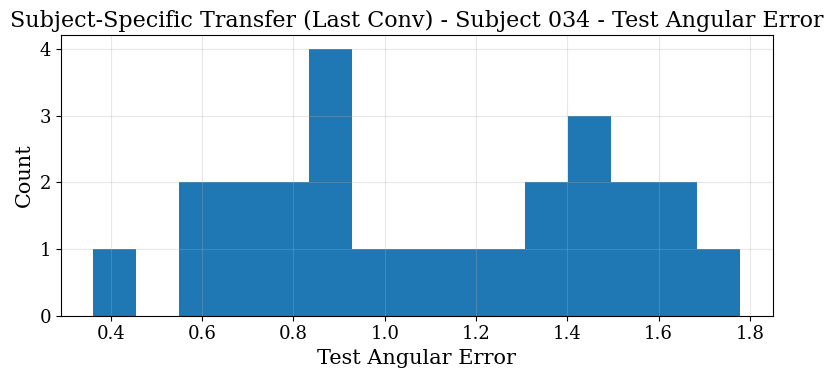

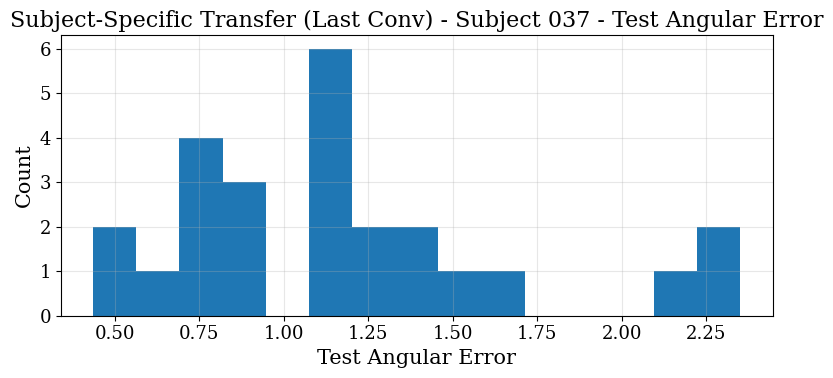

<Figure size 800x500 with 0 Axes>

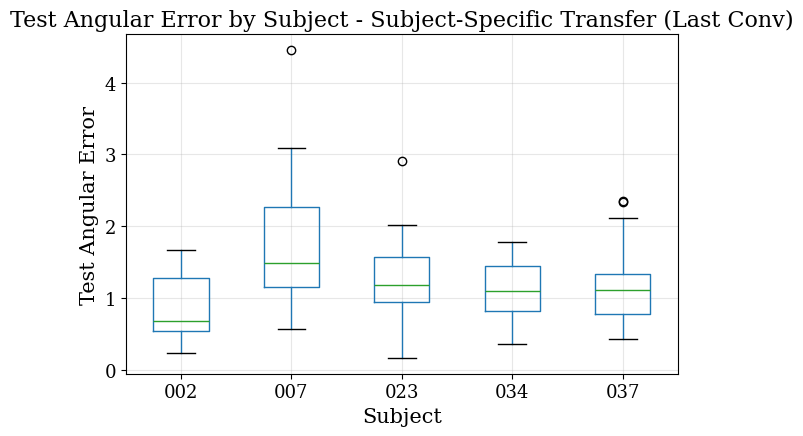

In [14]:
# show_subject_specific_tables(df_transfer_last_1_conv, EXPERIMENT_NAME)
plot_subject_specific_model_performance(df_transfer_last_1_conv, EXPERIMENT_NAME)
plot_subject_specific_error_distribution(df_transfer_last_1_conv, EXPERIMENT_NAME)
plot_subject_specific_boxplots(df_transfer_last_1_conv, EXPERIMENT_NAME)

<br/>

## **Experiment: Subject-Specific Transfer (Last Two Conv)**

In [15]:
EXPERIMENT_NAME = "Subject-Specific Transfer (Last Two Conv)"
CSV_PATH = "../results/subject_spec/subject_spec_transfer_last_two_conv.csv"

df_transfer_last_2_conv = load_results(CSV_PATH)
df_transfer_last_2_conv.head()

Loaded: ../results/subject_spec/subject_spec_transfer_last_two_conv.csv
Models found: 125


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,transfer_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,subject_spec_transfer_last_two_conv_002_0,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_0.pth,subject_spec_transfer,2,NaN,0,transfer,last_two_conv,2270,38,59,11,1.237309,1.239452,1.239452,22.636137,True
1,subject_spec_transfer_last_two_conv_002_1,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_1.pth,subject_spec_transfer,2,NaN,1,transfer,last_two_conv,2270,38,59,2,0.656562,0.507128,0.507128,13.902336,True
2,subject_spec_transfer_last_two_conv_002_2,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_2.pth,subject_spec_transfer,2,NaN,2,transfer,last_two_conv,2275,36,56,10,0.585792,0.516267,0.516267,18.245892,True
3,subject_spec_transfer_last_two_conv_002_3,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_3.pth,subject_spec_transfer,2,NaN,3,transfer,last_two_conv,2270,38,59,2,0.739606,0.697081,0.697081,17.806313,True
4,subject_spec_transfer_last_two_conv_002_4,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_4.pth,subject_spec_transfer,2,NaN,4,transfer,last_two_conv,2270,38,59,16,1.847295,1.786544,1.786544,21.612832,True


### Combined Results

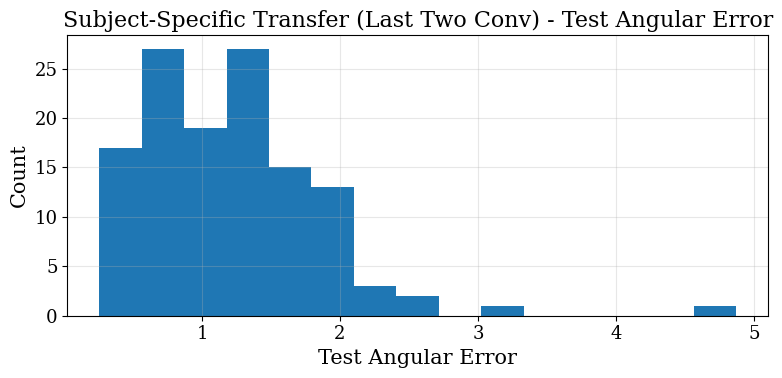

In [16]:
# print("Per-model test performance (Subject-Specific Transfer - Last Two Conv):")
# with pd.option_context("display.max_rows", None):
    # display(
        # df_transfer_last_2_conv[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
        # .sort_values("test_ang_error")
        # .reset_index(drop=True)
    # )

# Plot distribution of test angular error
plot_error_distribution(df_transfer_last_2_conv, EXPERIMENT_NAME)

### Per-Subject Results

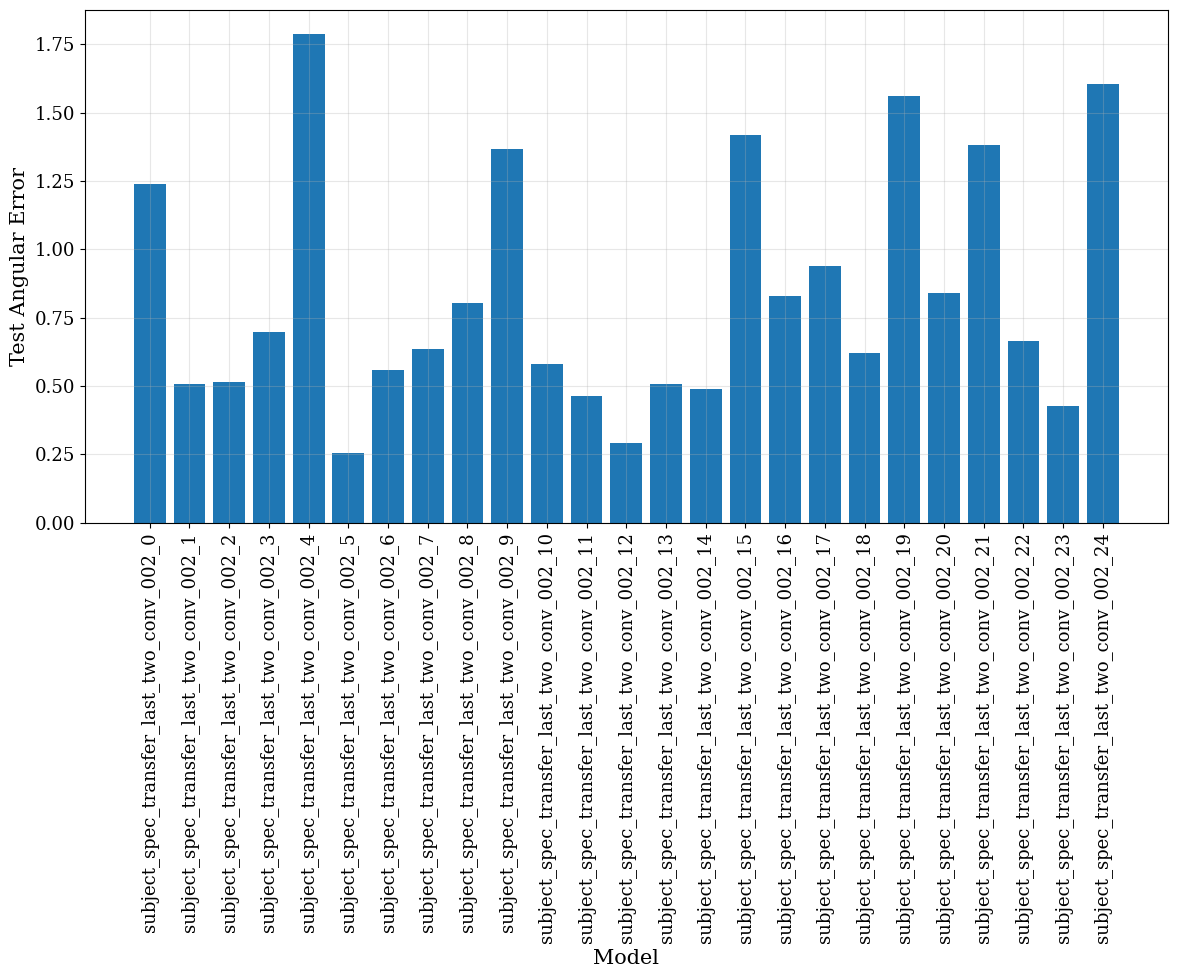

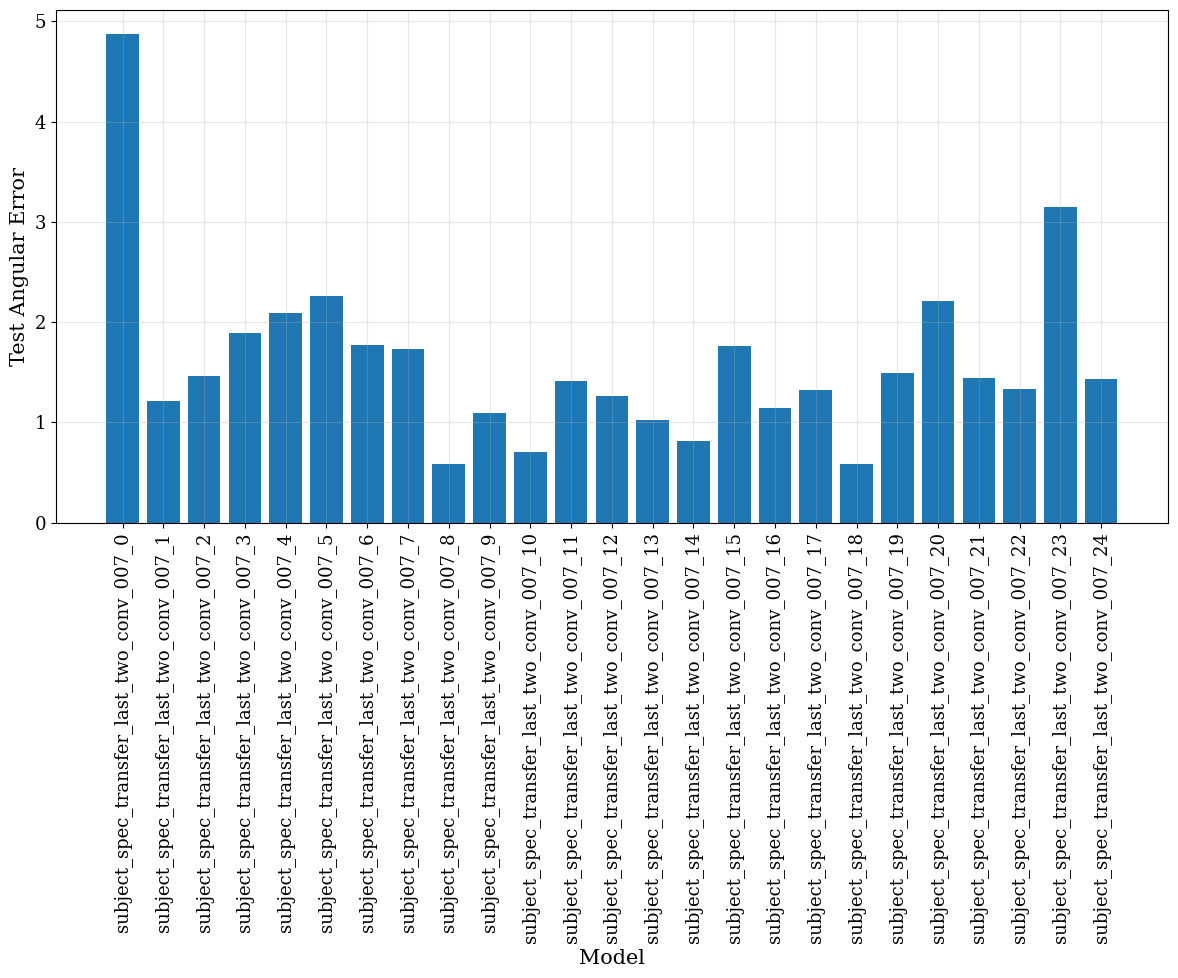

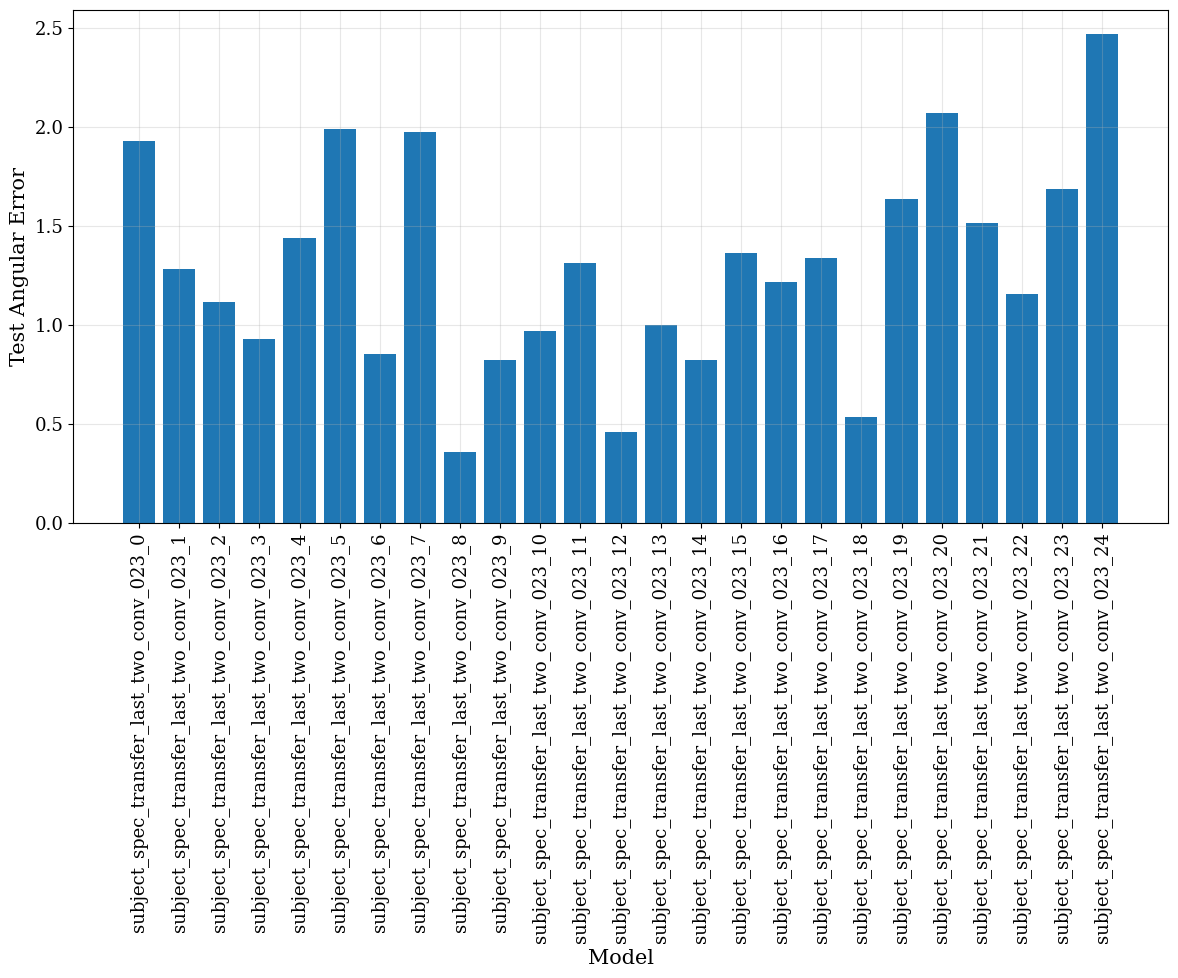

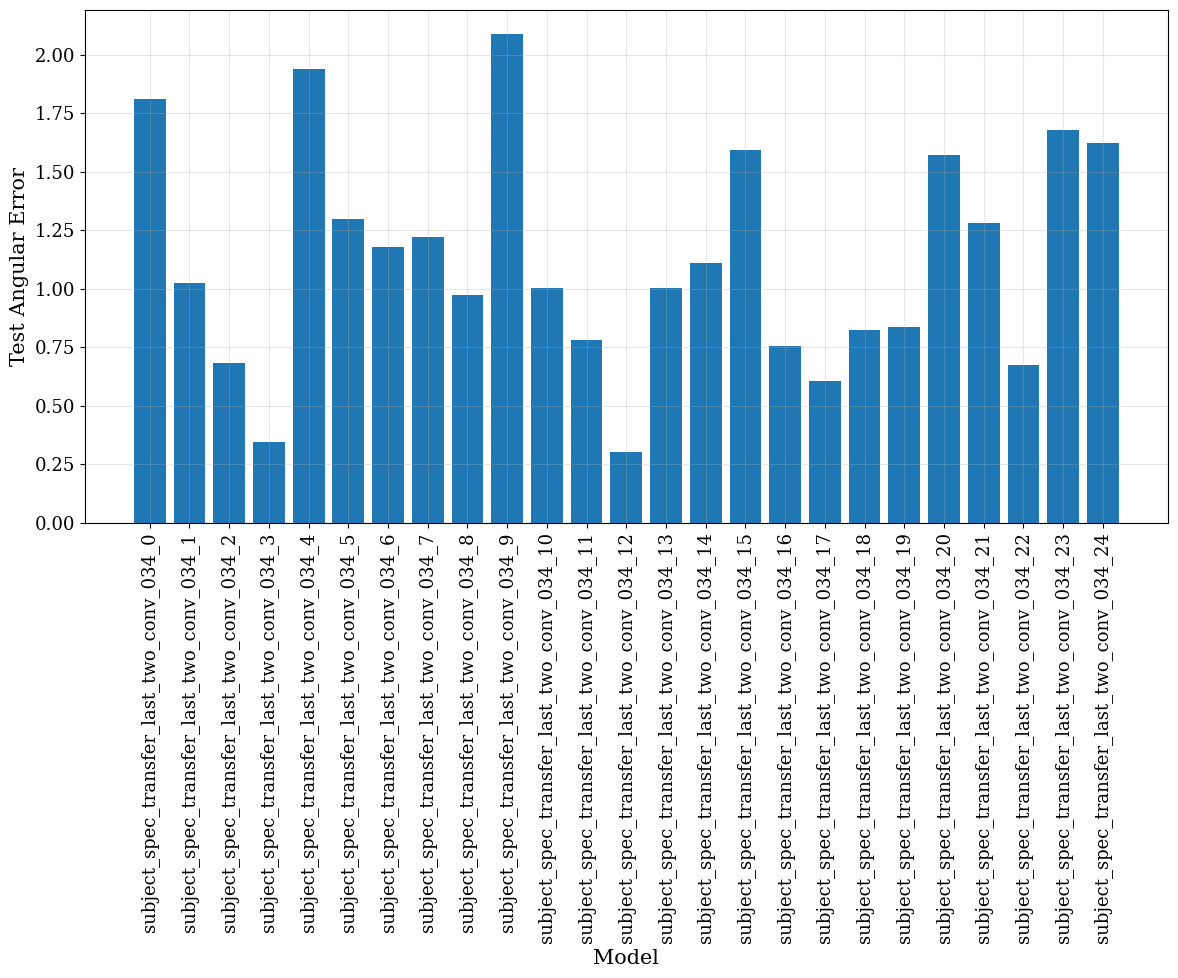

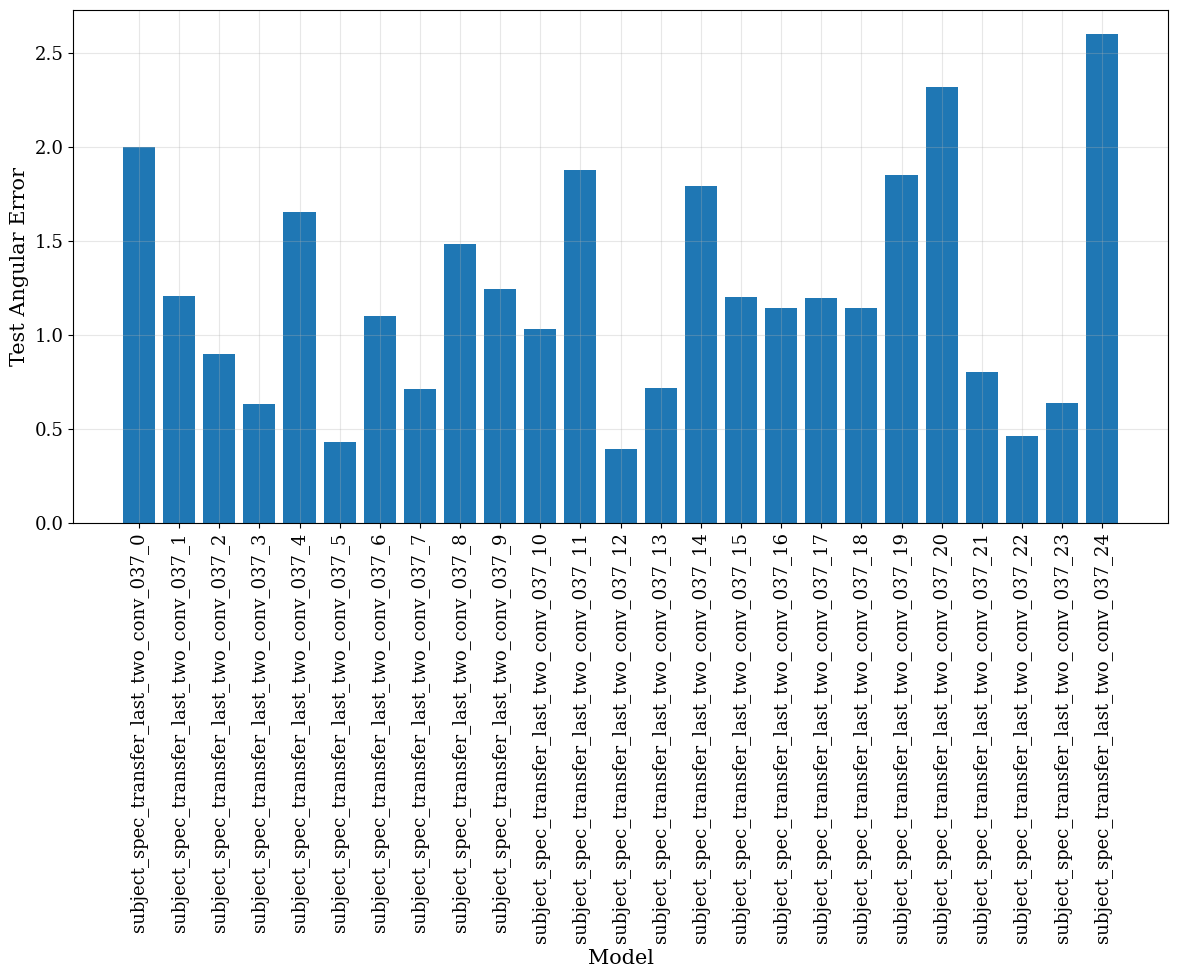

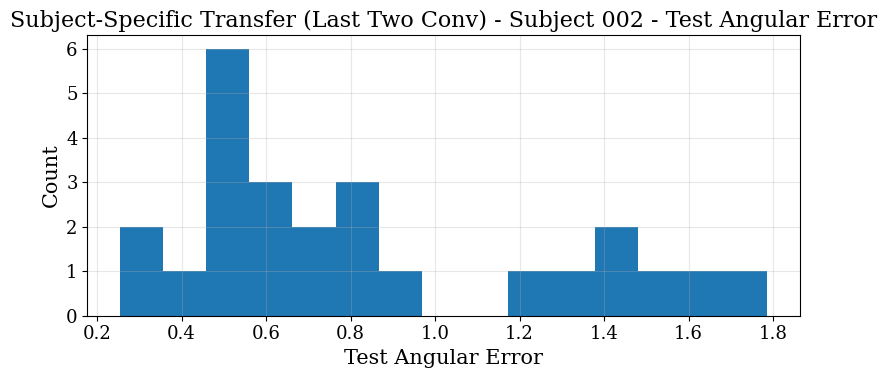

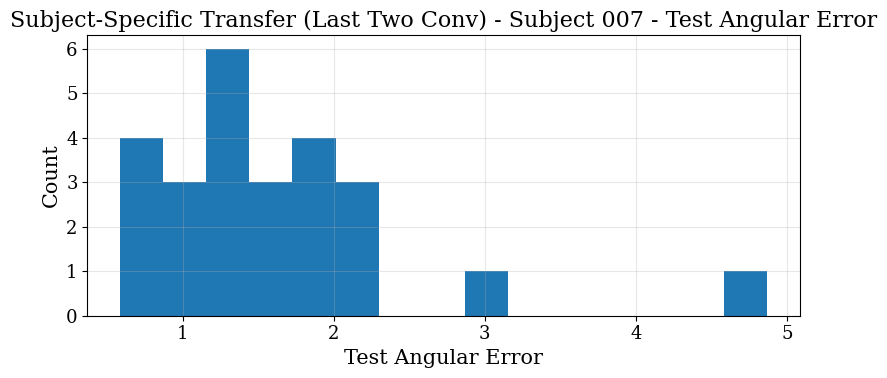

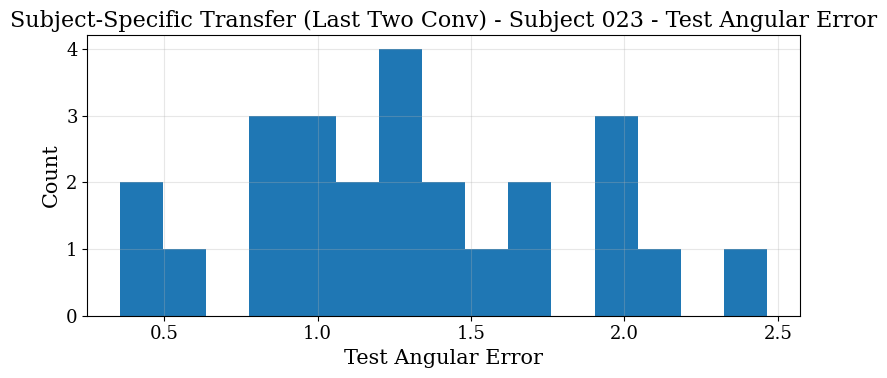

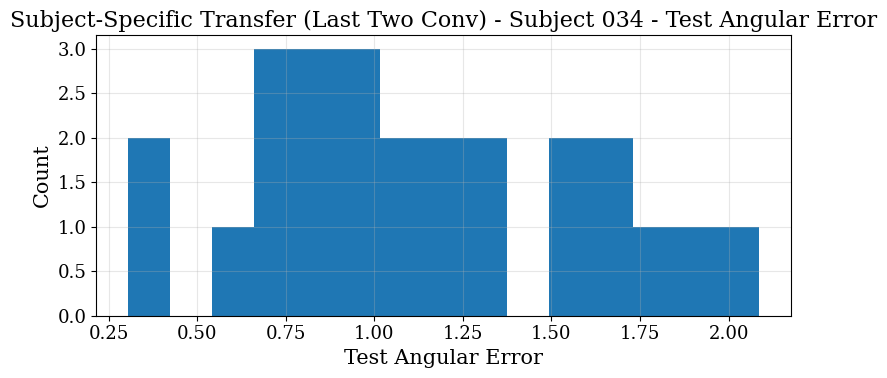

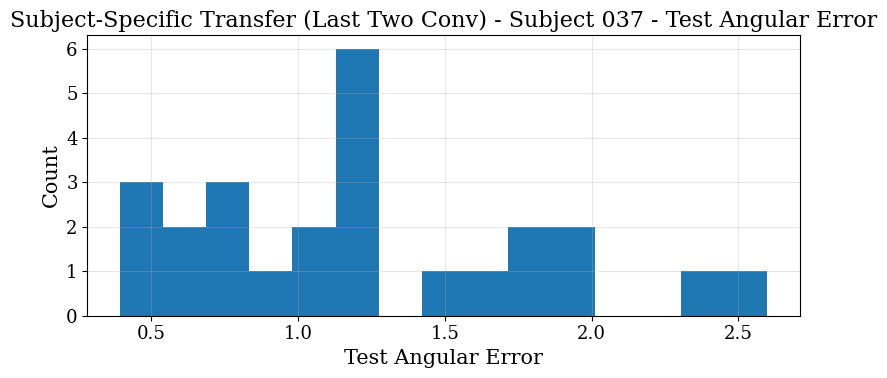

<Figure size 800x500 with 0 Axes>

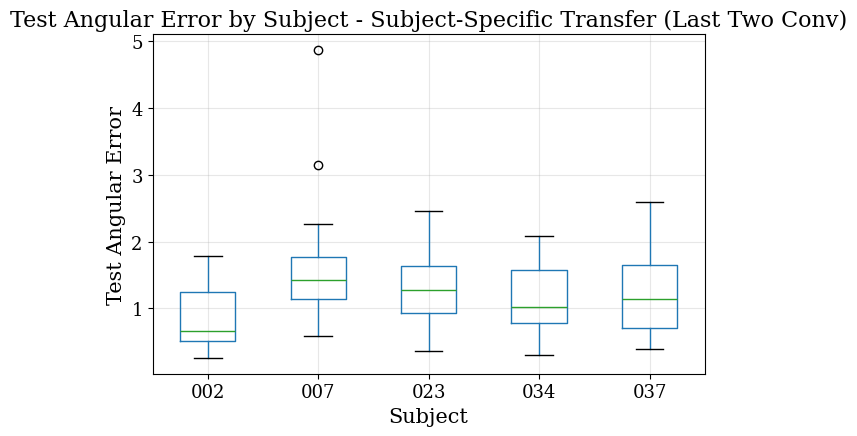

In [17]:
# show_subject_specific_tables(df_transfer_last_2_conv, EXPERIMENT_NAME)
plot_subject_specific_model_performance(df_transfer_last_2_conv, EXPERIMENT_NAME)
plot_subject_specific_error_distribution(df_transfer_last_2_conv, EXPERIMENT_NAME)
plot_subject_specific_boxplots(df_transfer_last_2_conv, EXPERIMENT_NAME)

<br/>

## **Experiment: Subject-Specific Transfer (Last Three Conv)**

In [18]:
EXPERIMENT_NAME = "Subject-Specific Transfer (Last Three Conv)"
CSV_PATH = "../results/subject_spec/subject_spec_transfer_last_three_conv.csv"

df_transfer_last_3_conv = load_results(CSV_PATH)
df_transfer_last_3_conv.head()

Loaded: ../results/subject_spec/subject_spec_transfer_last_three_conv.csv
Models found: 125


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,transfer_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,subject_spec_transfer_last_three_conv_002_0,results\models\subject_spec_transfer_last_thre...,results\models\gen_loto_0.pth,subject_spec_transfer,2,NaN,0,transfer,last_three_conv,2270,38,59,26,0.975358,0.980231,0.980231,26.054432,True
1,subject_spec_transfer_last_three_conv_002_1,results\models\subject_spec_transfer_last_thre...,results\models\gen_loto_1.pth,subject_spec_transfer,2,NaN,1,transfer,last_three_conv,2270,38,59,4,1.003688,0.864372,0.864372,15.155348,True
2,subject_spec_transfer_last_three_conv_002_2,results\models\subject_spec_transfer_last_thre...,results\models\gen_loto_2.pth,subject_spec_transfer,2,NaN,2,transfer,last_three_conv,2275,36,56,5,0.493688,0.461566,0.461566,16.136403,True
3,subject_spec_transfer_last_three_conv_002_3,results\models\subject_spec_transfer_last_thre...,results\models\gen_loto_3.pth,subject_spec_transfer,2,NaN,3,transfer,last_three_conv,2270,38,59,2,0.620836,0.558451,0.558451,14.290948,True
4,subject_spec_transfer_last_three_conv_002_4,results\models\subject_spec_transfer_last_thre...,results\models\gen_loto_4.pth,subject_spec_transfer,2,NaN,4,transfer,last_three_conv,2270,38,59,5,1.633972,1.569142,1.569142,15.547368,True


### Combined Results

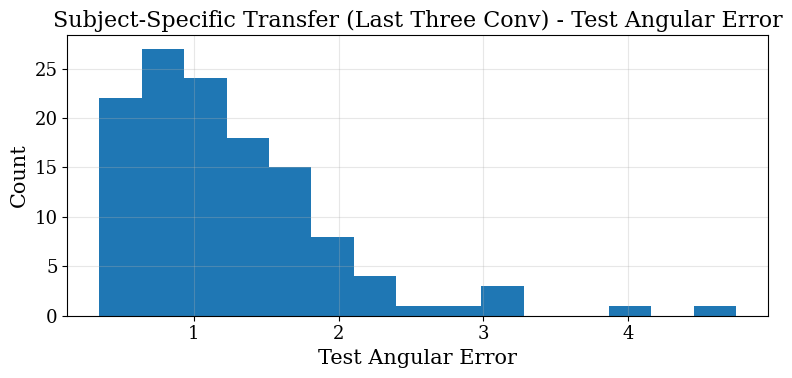

In [19]:
# print("Per-model test performance (Subject-Specific Transfer - Last Three Conv):")
# with pd.option_context("display.max_rows", None):
    # display(
        # df_transfer_last_three_conv[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
        # .sort_values("test_ang_error")
        # .reset_index(drop=True)
    # )

# Plot distribution of test angular error
plot_error_distribution(df_transfer_last_3_conv, EXPERIMENT_NAME)

### Per-Subject Results

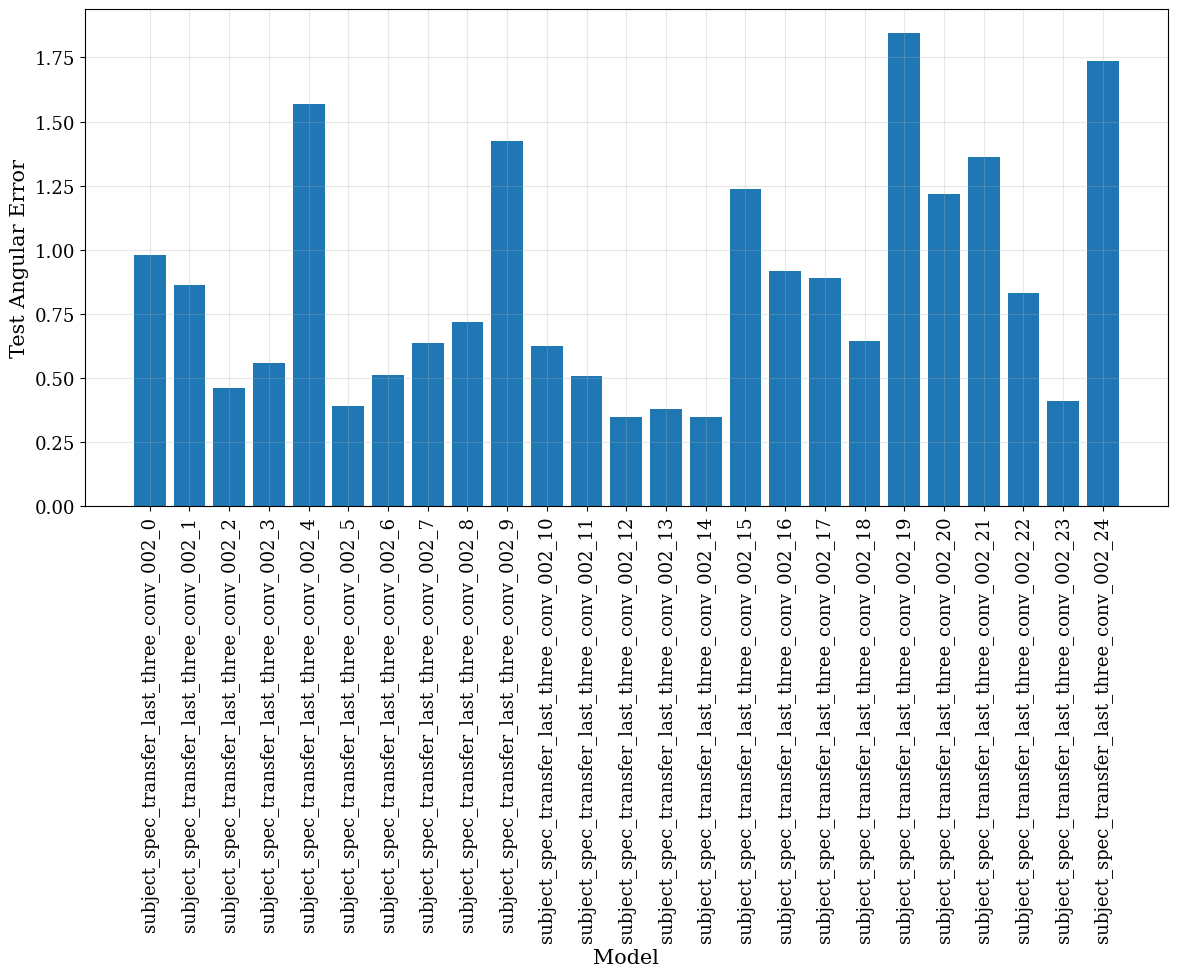

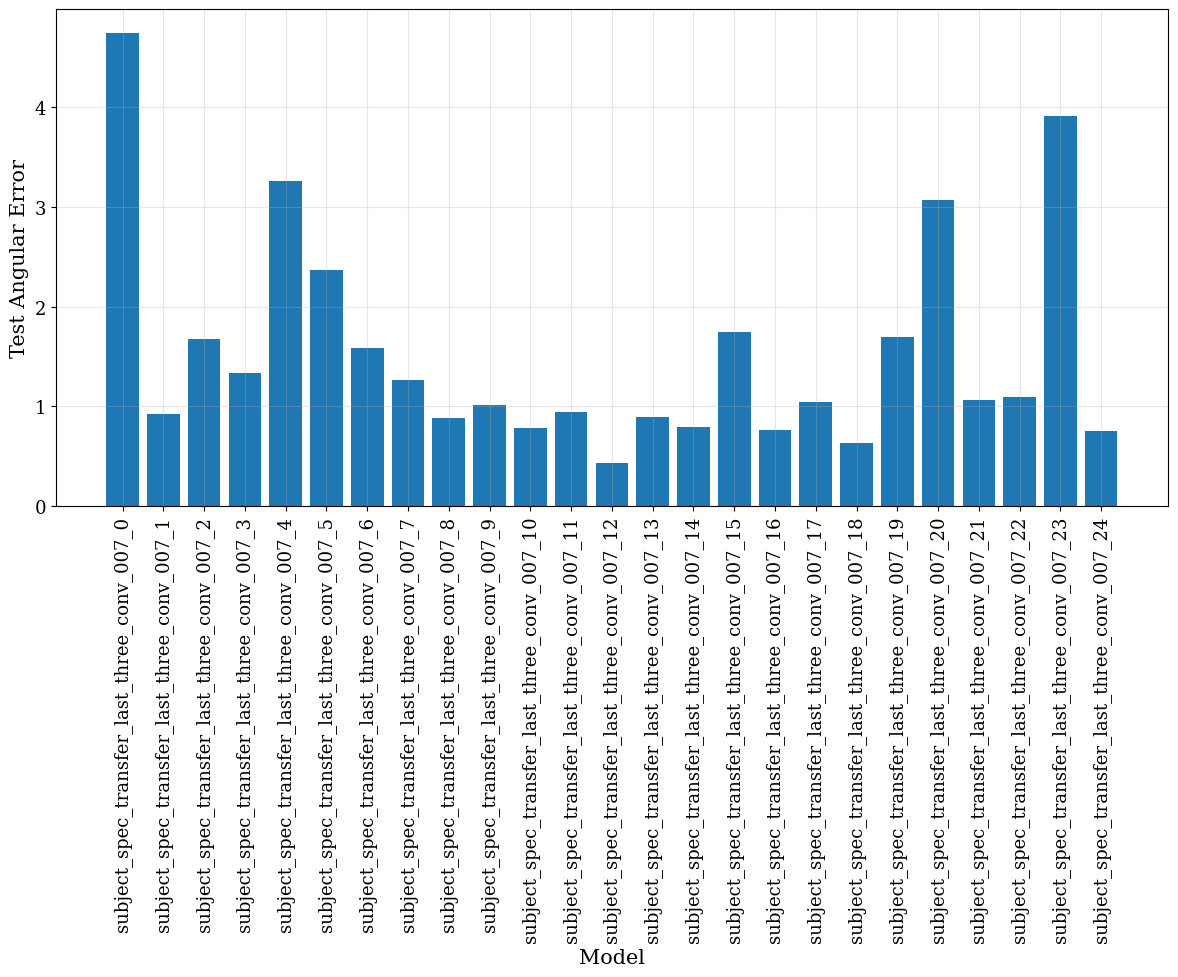

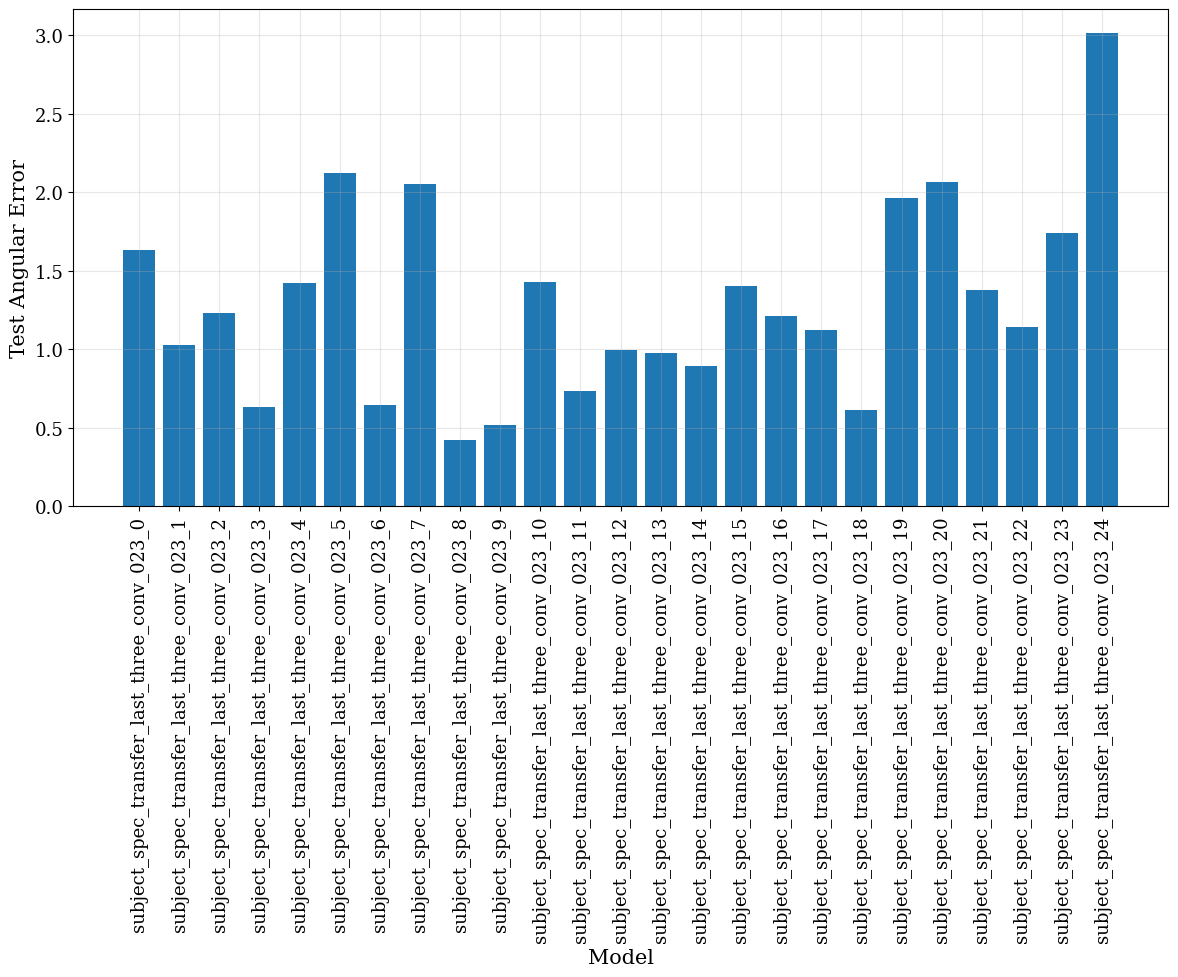

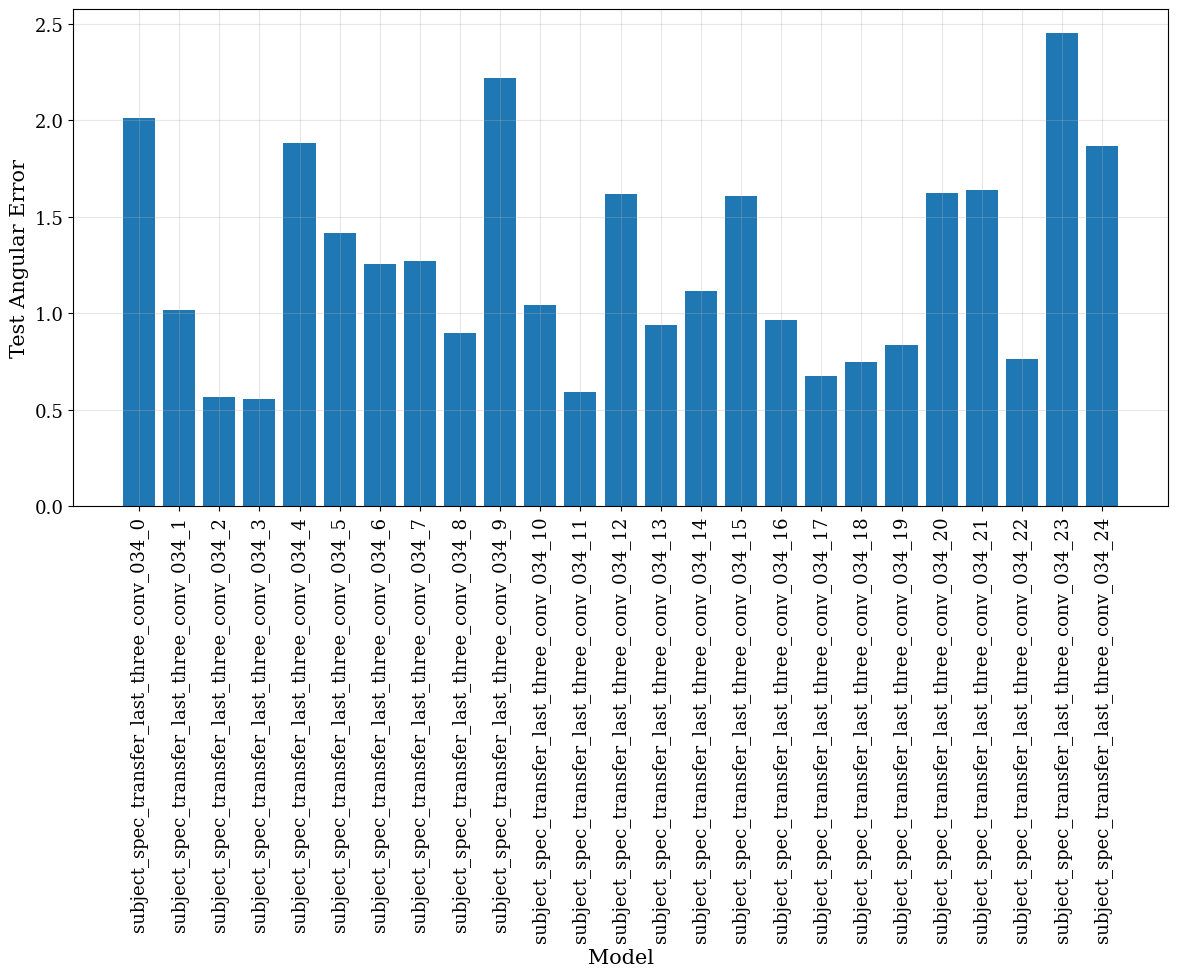

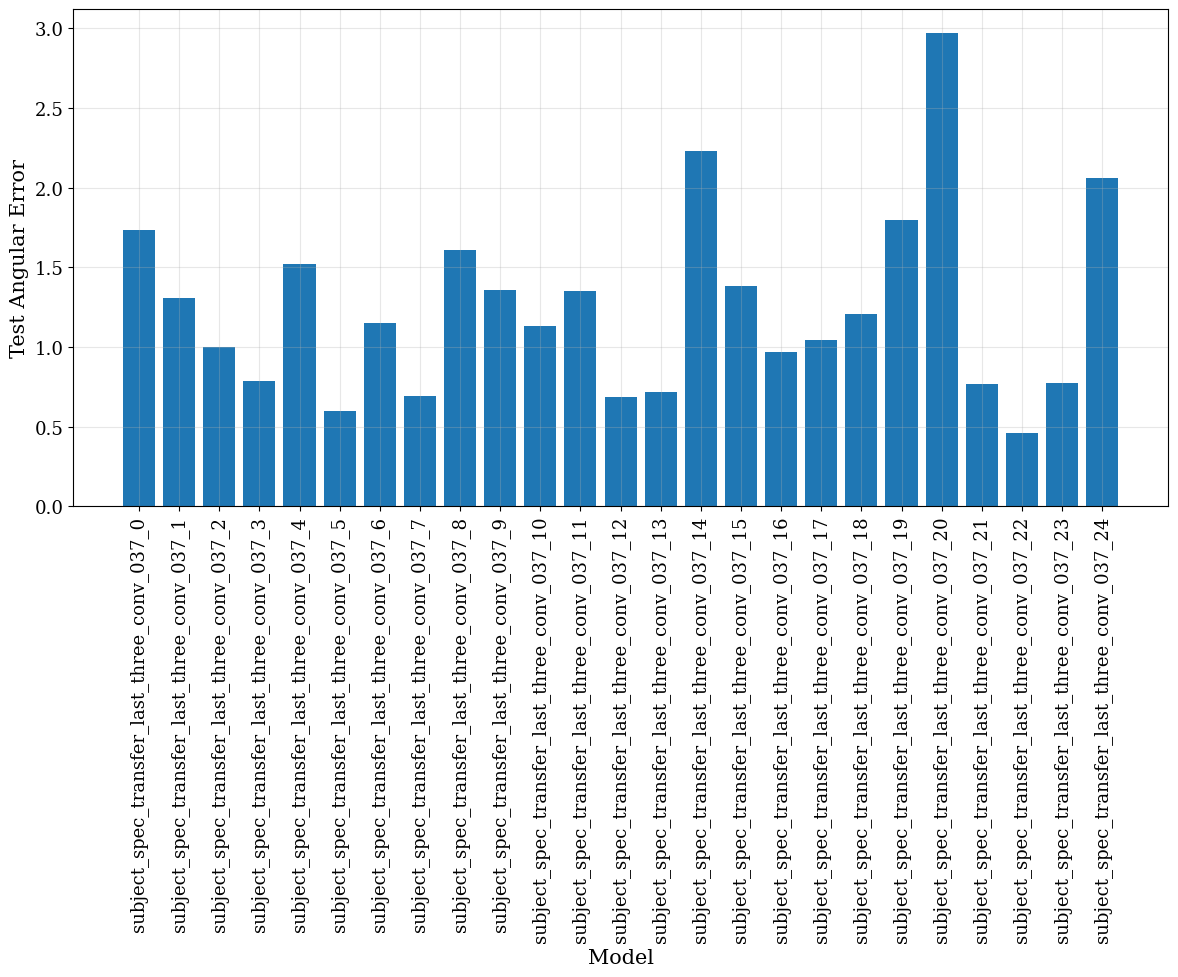

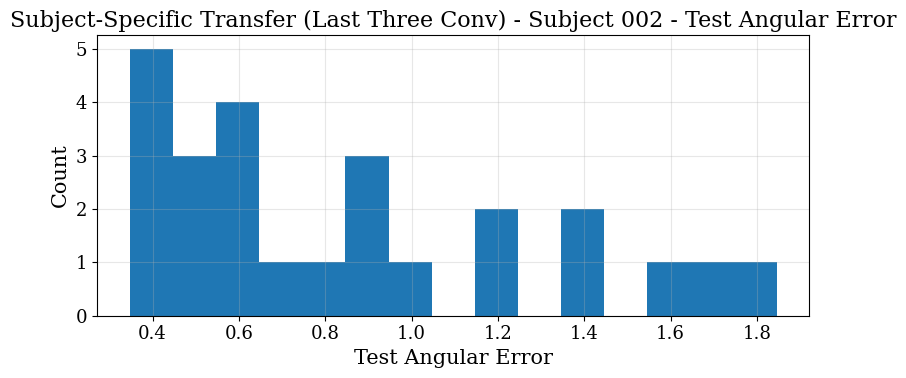

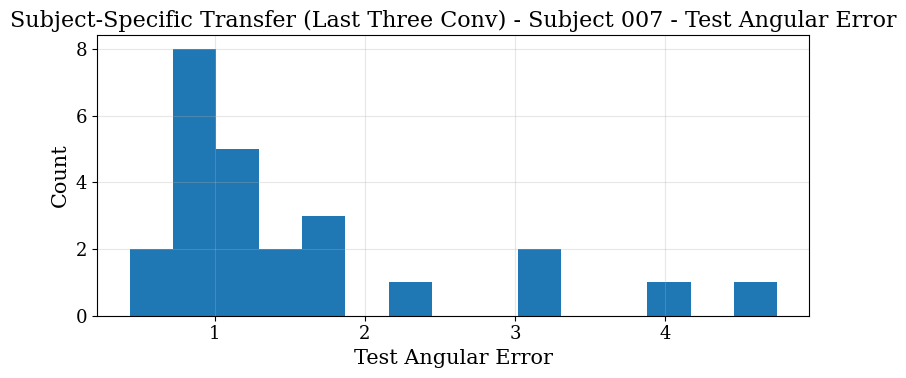

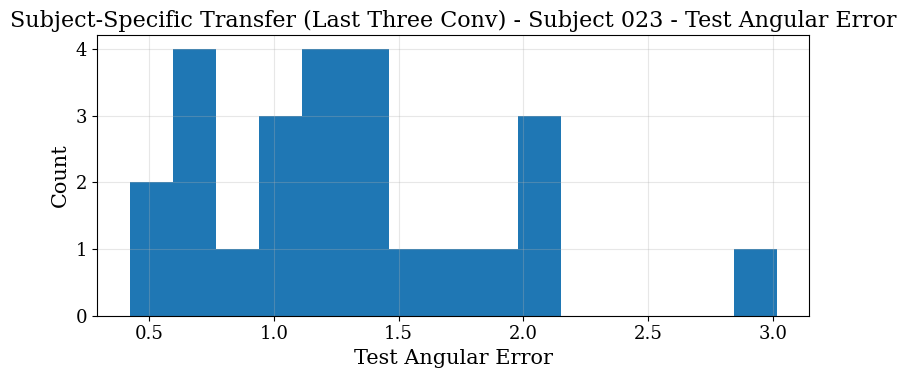

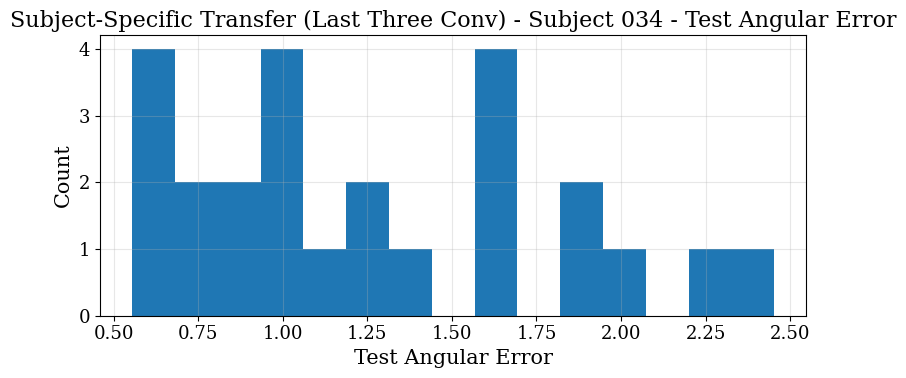

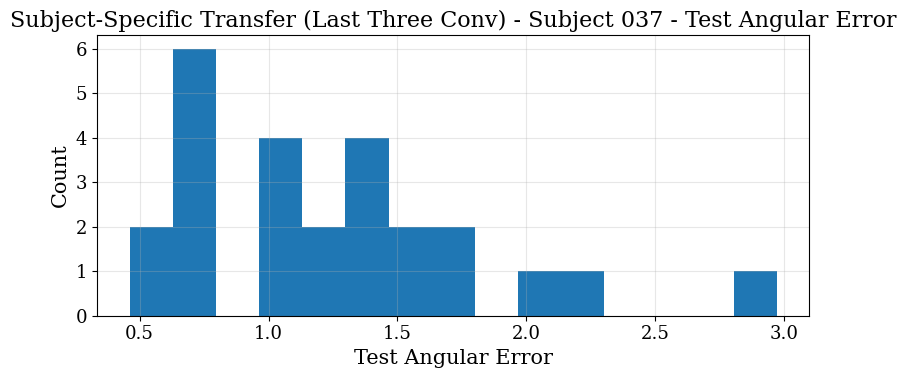

<Figure size 800x500 with 0 Axes>

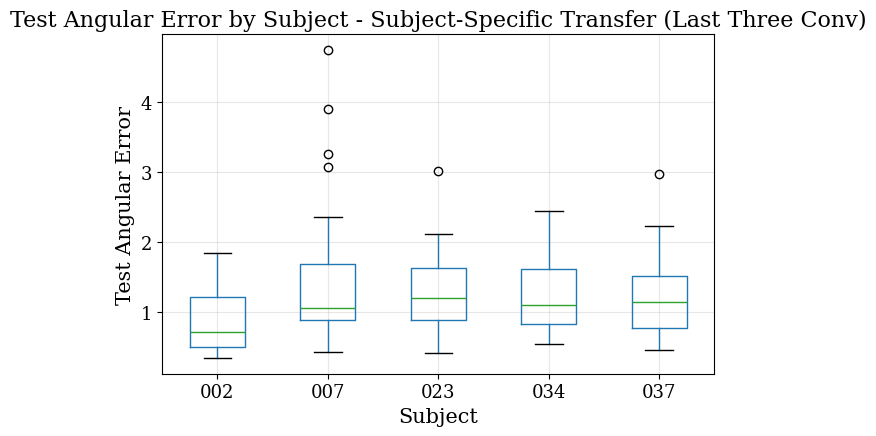

In [20]:
# show_subject_specific_tables(df_transfer_last_3_conv, EXPERIMENT_NAME)
plot_subject_specific_model_performance(df_transfer_last_3_conv, EXPERIMENT_NAME)
plot_subject_specific_error_distribution(df_transfer_last_3_conv, EXPERIMENT_NAME)
plot_subject_specific_boxplots(df_transfer_last_3_conv, EXPERIMENT_NAME)

<br/>

## **Experiment Comparison**

In [21]:
# Runtime
runtime_dfs = {
    "gen_loso": df_loso,
    "gen_loto": df_loto,
    "subject_spec_scratch": df_scratch,
    "subject_spec_transfer_head_only": df_transfer_head,
    "subject_spec_transfer_last_conv": df_transfer_last_1_conv,
    "subject_spec_transfer_last_two_conv": df_transfer_last_2_conv,
    "subject_spec_transfer_last_three_conv": df_transfer_last_3_conv,
}

for name, df in runtime_dfs.items():
    minutes = df["runtime_sec"].sum() / 60
    print(f"Runtime {name}: {minutes:.1f} min")

Runtime gen_loso: 195.7 min
Runtime gen_loto: 242.5 min
Runtime subject_spec_scratch: 191.4 min
Runtime subject_spec_transfer_head_only: 31.4 min
Runtime subject_spec_transfer_last_conv: 135.8 min
Runtime subject_spec_transfer_last_two_conv: 34.1 min
Runtime subject_spec_transfer_last_three_conv: 34.9 min


In [22]:
df_transfer_head["experiment_type"] = "transfer_head"
df_transfer_last_1_conv["experiment_type"] = "transfer_last_1_conv"
df_transfer_last_2_conv["experiment_type"] = "transfer_last_2_conv"
df_transfer_last_3_conv["experiment_type"] = "transfer_last_3_conv"

df_all = pd.concat(
    [
        df_loso,
        df_loto,
        df_loto_reserved,
        df_scratch,
        df_transfer_head,
        df_transfer_last_1_conv,
        df_transfer_last_2_conv,
        df_transfer_last_3_conv
    ],
    ignore_index=True
)

print(df_all.shape)
df_all.head()

(821, 18)


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early,transfer_mode
0,gen_loso_001,results\models\gen_loso_001.pth,NaN,general_loso,NaN,1.0,NaN,scratch,106541.0,638.0,957,3.0,11.867901,11.358718,11.358718,225.617119,True,NaN
1,gen_loso_002,results\models\gen_loso_002.pth,NaN,general_loso,NaN,2.0,NaN,scratch,105769.0,946.0,1421,3.0,5.665264,5.387886,5.387886,223.536461,True,NaN
2,gen_loso_003,results\models\gen_loso_003.pth,NaN,general_loso,NaN,3.0,NaN,scratch,105831.0,922.0,1383,1.0,11.850139,11.886454,11.886454,179.096308,True,NaN
3,gen_loso_004,results\models\gen_loso_004.pth,NaN,general_loso,NaN,4.0,NaN,scratch,105715.0,968.0,1453,2.0,10.516744,10.495703,10.495703,201.376590,True,NaN
4,gen_loso_005,results\models\gen_loso_005.pth,NaN,general_loso,NaN,5.0,NaN,scratch,105702.0,973.0,1461,11.0,7.549269,7.430896,7.430896,404.216634,True,NaN


In [23]:
# Summary statistics per experiment
summary = (
    df_all.groupby("experiment_type")["test_ang_error"]
    .agg(
        n_models="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(3)
    #.sort_values("mean")
)

display(summary)

,n_models,mean,median,std,min,max
experiment_type,,,,,,
general_loso,46,8.952,9.223,2.539,1.959,11.886
general_loto,25,1.601,1.566,0.344,1.180,2.466
general_loto_reserved_eval,125,11.863,10.932,6.961,0.667,31.572
subject_spec_scratch,125,9.593,9.286,4.373,0.263,17.103
transfer_head,125,1.500,1.313,0.981,0.097,7.191
transfer_last_1_conv,125,1.228,1.154,0.652,0.165,4.454
transfer_last_2_conv,125,1.216,1.155,0.650,0.254,4.871
transfer_last_3_conv,125,1.243,1.049,0.721,0.346,4.746


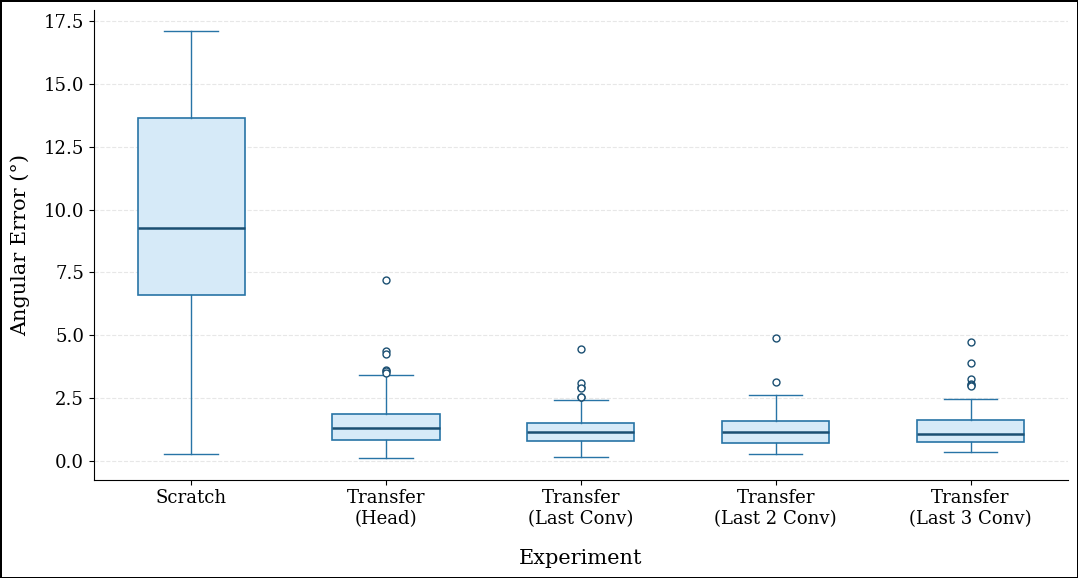

In [24]:
# ==================== FILTER DATA ====================

df_ss = df_all[
    df_all["experiment_type"].isin([
        "subject_spec_scratch",
        "transfer_head",
        "transfer_last_1_conv",
        "transfer_last_2_conv",
        "transfer_last_3_conv"
    ])
].copy()

# ==================== PREP DATA ====================

order = [
    "subject_spec_scratch",
    "transfer_head",
    "transfer_last_1_conv",
    "transfer_last_2_conv",
    "transfer_last_3_conv"
]

data = [
    df_ss.loc[df_ss["experiment_type"] == exp, "test_ang_error"].dropna()
    for exp in order
]

# ==================== PLOT ====================

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(1)

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color="#1B4F72", linewidth=1.8),
    boxprops=dict(edgecolor="#2874A6", linewidth=1.2),
    whiskerprops=dict(color="#2874A6", linewidth=1.0),
    capprops=dict(color="#2874A6", linewidth=1.0),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="#1B4F72",
        markersize=5,
        linestyle="none"
    )
)

# Color boxes
for patch in bp["boxes"]:
    patch.set_facecolor("#D6EAF8")

# Labels
ax.set_xlabel("Experiment", labelpad=15)
ax.set_ylabel("Angular Error (°)", labelpad=10)

ax.set_xticklabels([
    "Scratch",
    "Transfer\n(Head)",
    "Transfer\n(Last Conv)",
    "Transfer\n(Last 2 Conv)",
    "Transfer\n(Last 3 Conv)"
])

# Grid + styling
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.xaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("img/ss_results_boxplot.pdf", bbox_inches="tight")
plt.show()

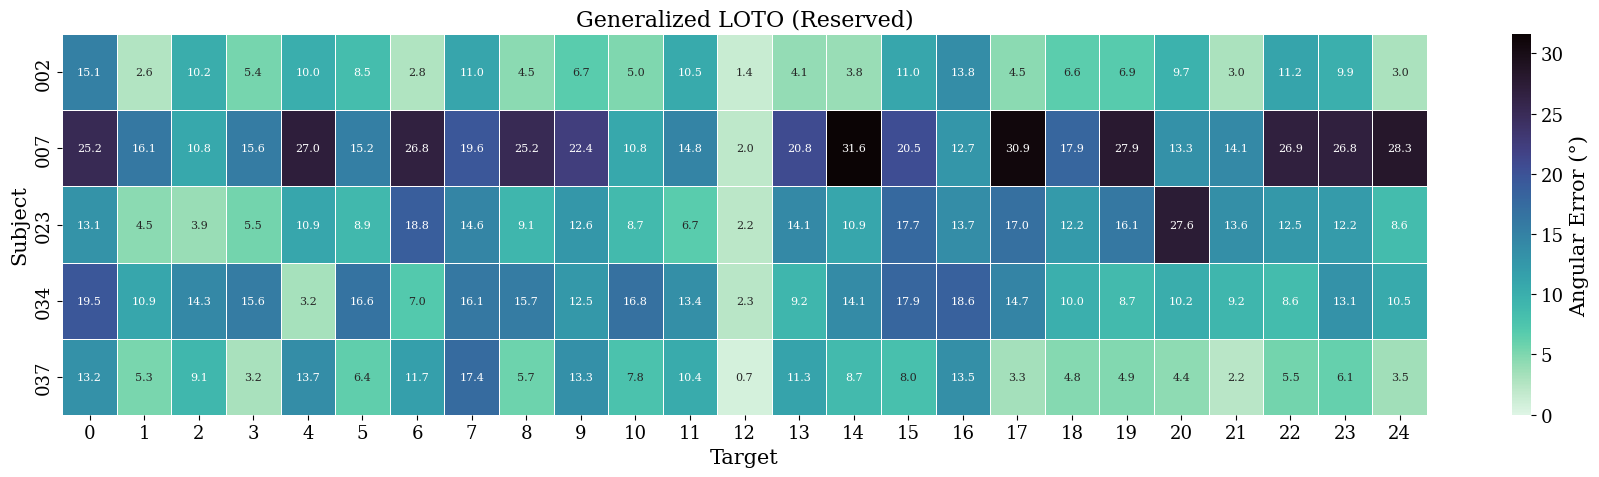

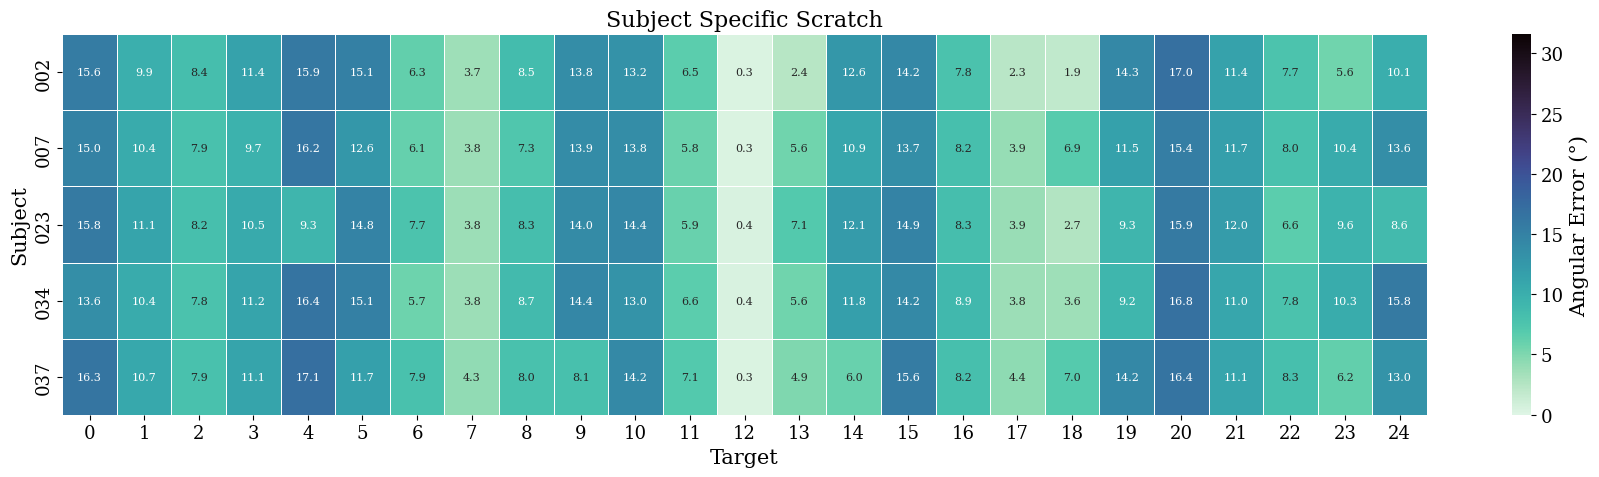

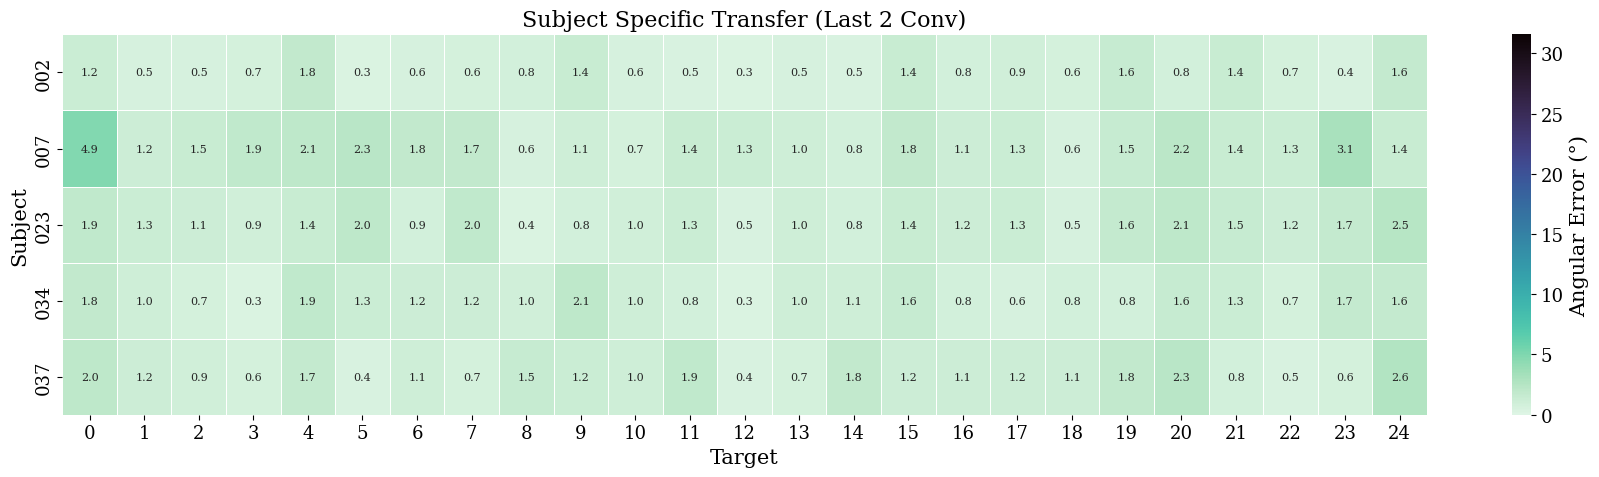

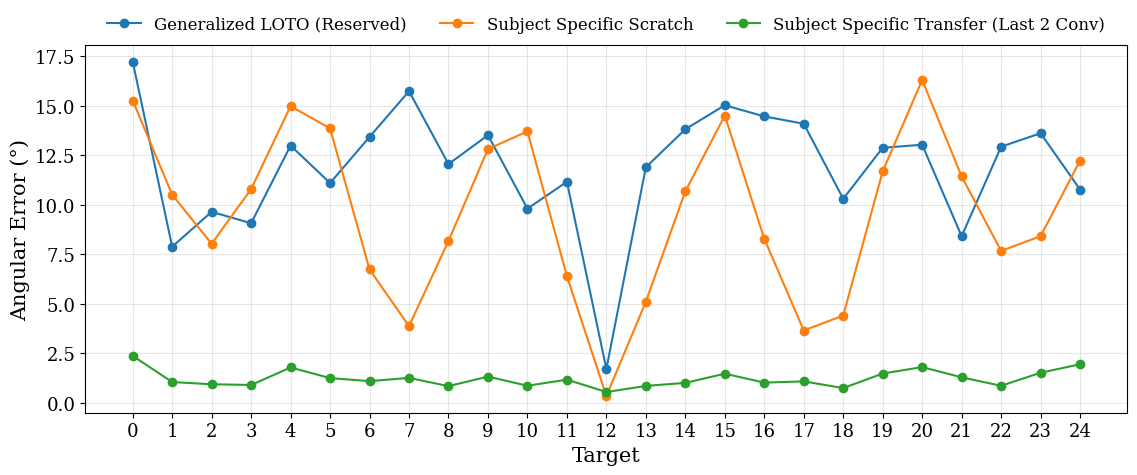

In [25]:
# ==================== SETTINGS ====================
vmin = 0
vmax = max([
    df_loto_reserved["test_ang_error"].max(),
    df_scratch["test_ang_error"].max(),
    df_transfer_last_2_conv["test_ang_error"].max()
])

# ==================== HEATMAP FUNCTION ====================
def plot_heatmap(df, title, filename):
    df = df.copy()
    df["subject_spec_id"] = df["subject_spec_id"].astype(str).str.zfill(3)
    df["held_out_target"] = df["held_out_target"].astype(int)

    heatmap_data = df.pivot(
        index="subject_spec_id",
        columns="held_out_target",
        values="test_ang_error"
    )

    plt.figure(figsize=(18, 5))

    sns.heatmap(
        heatmap_data,
        cmap="mako_r",
        annot=True,
        fmt=".1f",
        linewidths=0.4,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": "Angular Error (°)"},
        annot_kws={"size": 8}
    )

    plt.xlabel("Target")
    plt.ylabel("Subject")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(f"img/{filename}.pdf", bbox_inches="tight")
    plt.show()


# ==================== HEATMAPS ====================
plot_heatmap(df_loto_reserved, "Generalized LOTO (Reserved)", "heatmap_loto")
plot_heatmap(df_scratch, "Subject Specific Scratch", "heatmap_scratch")
plot_heatmap(df_transfer_last_2_conv, "Subject Specific Transfer (Last 2 Conv)", "heatmap_transfer_l2")


# ==================== LINE PLOT ====================
def mean_error_per_target(df):
    return df.groupby("held_out_target")["test_ang_error"].mean().sort_index()

err_loto = mean_error_per_target(df_loto_reserved)
err_scratch = mean_error_per_target(df_scratch)
err_transfer = mean_error_per_target(df_transfer_last_2_conv)

plt.figure(figsize=(12, 5))

plt.plot(err_loto.index, err_loto.values, label="Generalized LOTO (Reserved)", marker="o")
plt.plot(err_scratch.index, err_scratch.values, label="Subject Specific Scratch", marker="o")
plt.plot(err_transfer.index, err_transfer.values, label="Subject Specific Transfer (Last 2 Conv)", marker="o")

plt.xlabel("Target")
plt.ylabel("Angular Error (°)")
plt.xticks(err_loto.index)

plt.legend(
    fontsize=12,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3
)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("img/target_comparison.pdf", bbox_inches="tight")
plt.show()

<br/>